# 23 · 잠재변수: 보이지 않는 선택을 더해서 없애기 (혼합 모형과 EM)

**이번 질문:** 데이터가 두 봉우리에서 왔는데 각 점이 어느 봉우리에서 왔는지는 적혀 있지 않습니다. 그래도 밀도를 쓰고, 학습하고, "이 점은 어느 봉우리에서 왔나"를 되물을 수 있을까요?

12번에서는 점 하나가 Gaussian 하나에서 나온다고 두었습니다. 실제 데이터는 그렇게 생기지 않습니다. 손글씨 숫자는 0–9라는 **보이지 않는 선택**이 먼저 있고 그다음에 이미지가 그려집니다.
이 노트북은 그 선택을 잠재변수 $z$로 두고, $z$를 **더해서 없앤** 밀도 $p(x)=\sum_z p(z)p(x\mid z)$를 씁니다. 그다음 Bayes 규칙으로 $z$를 되묻고(책임확률), 그 책임확률이 미분에도 학습(EM)에도 그대로 나타나는 것을 봅니다.
주변 밀도 → 책임확률 → 미분 → EM → 샘플과 잡음 뒤 복원 순서로 갑니다. 여기서 만드는 닫힌식은 24·32·34번에서 신경망이 배운 결과를 대조하는 **정답지**가 됩니다.

- 준비물: [02](../00_기초/02_probability_and_losses.ipynb)의 결합·조건부 확률과 softmax 안정화, [12](../02_연결/12_gaussian_information.ipynb)의 Gaussian 로그 밀도·MLE·Cholesky 샘플, [00b](../00_기초/00b_vectorization.ipynb)의 축 합·브로드캐스팅, [01](../00_기초/01_gradients_and_learning.ipynb)의 중심차분.
- 도착점: 혼합 밀도·책임확률·score·EM·최적 복원을 직접 구현하고 손계산·중심차분·닫힌식과 대조합니다.
- 다음 연결: [24 ELBO](24_elbo.ipynb)는 잠재를 더하는 합이 너무 커서 계산할 수 없을 때 무엇을 대신 최대화하는지 다룹니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 잠재 $z$를 **더해서 없애면** 관측의 밀도가 됩니다. $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$이고, 코드에서는 성분 로그 항의 logsumexp입니다. `logsumexp_rows(component_log_terms(x, pi, mu, sigma))`.
2. 거꾸로 묻는 답이 **책임확률** $r_k(x)=p(z=k\mid x)$이고, 같은 로그 항의 softmax입니다. 밀도의 미분도, 학습의 갱신식도 전부 이 $r$의 가중합으로 쓰입니다. `softmax_rows(component_log_terms(x, pi, mu, sigma))`.
3. **EM**은 E 단계에서 $r$을 구하고 M 단계에서 $r$로 가중한 비율·평균·분산을 다시 재는 반복입니다. 평균 로그우도는 반복마다 내려가지 않습니다. `pi = R.sum(axis=0) / len(x)`.

| 기호 | shape | 의미 |
|---|---|---|
| $x$ | $(N,)$ | 관측 $N$개 (2차원 판은 $(N,2)$) |
| $z$ | $(N,)$ | 각 관측이 어느 성분에서 왔는지. **보이지 않는 값** |
| $\pi,\mu,\sigma$ | $(K,)$ | 성분 $K$개의 비율·평균·표준편차 |
| $r$ | $(N,K)$ | 책임확률. 행마다 합이 1 |

로그의 밑은 $e$이며 정보량의 단위는 nat입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/mixture_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3절부터: 01번 3절의 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/mixture_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.mixture_plots import (
    plot_marginal_sum, plot_mixture2_density, plot_responsibility, plot_score_field,
    plot_em_progress, plot_em2_progress, plot_ancestral_sampling, plot_denoiser_curves, plot_em_variants,
)

# 3) 그림 설정. 배열 출력은 소수 5자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=5, suppress=True)
print("NumPy", np.__version__, "· 잠재변수·혼합 모형 준비 완료")

NumPy 2.4.6 · 잠재변수·혼합 모형 준비 완료


### 📎 이 노트북의 예시: 두 봉우리 혼합, 2차원 혼합, MNIST 클래스별 Gaussian

- **두 봉우리 혼합(1차원).** 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$인 Gaussian 두 개를 섞은 분포입니다. 생성 단원(23–35번)이 함께 쓰는 공통 상황이고, 밀도·책임확률·미분·최적 복원이 모두 닫힌식이라 **정답지**로 쓰기 좋습니다.
- **2차원 혼합.** 같은 규약의 2차원 판입니다. 평균이 두 곳, 공분산이 기울어져 있어 "성분마다 다른 모양"을 눈으로 볼 수 있습니다.
- **MNIST 클래스별 Gaussian.** 앞 5,000장을 숫자별로 나눠 화소마다 평균·표준편차를 잰 것(12번 4절)이 성분 10개짜리 혼합입니다. 고정 예시 7 한 장에 "너는 어느 숫자에서 왔니"를 물어봅니다.

> **용어**
>
> - **잠재변수(latent variable)** $z$: 데이터를 만들 때 먼저 정해졌지만 관측에는 적혀 있지 않은 값. 여기서는 "어느 봉우리에서 뽑았나"(0 또는 1)입니다. 코드에서는 성분 번호 정수 배열입니다.
> - **MNIST**: 손으로 쓴 숫자 0–9를 28×28 흑백 이미지로 모은 데이터셋. 이 노트북에서는 "숫자 10개 중 하나를 고른 뒤 그 숫자를 쓴다"는 잠재변수 이야기의 예로 씁니다.
> - **성분(component)** $k$: 혼합을 이루는 분포 하나. 이 노트북에서 성분 수는 $K$이고 1차원 예제는 $K=2$입니다.

아래 두 셀은 실행만 하고 넘어가도 됩니다. 두 번에 나누어 공부해도 됩니다. 먼저 1–3절의 밀도·책임확률·미분을 보고, 다음에 4–5절의 학습과 샘플링을 진행하세요.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `np.bincount(mnist_y, minlength=10)`: 0부터 9까지 각 숫자가 몇 번 나오는지 센 `(10,)` 배열입니다.
> - `mnist_examples[7].reshape(-1)`: 28×28 이미지를 길이 784의 한 줄로 폅니다. `-1`은 "나머지를 알아서"입니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_X_all, mnist_y_all, _, _ = load_mnist()                        # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_y = mnist_X_all[:5000], mnist_y_all[:5000]            # (5000, 784), (5000,): 학습 집합 앞 5,000장
mnist_7 = mnist_examples[7].reshape(-1)                              # (784,): 고정 예시 7을 한 줄로 편 것
print("MNIST", mnist_X.shape, "· 숫자별 장수", np.bincount(mnist_y, minlength=10), "· 예시 7의 잉크 합", mnist_7.sum().round(1))

MNIST (5000, 784) · 숫자별 장수 [479 563 488 493 535 434 501 550 462 495] · 예시 7의 잉크 합 49.5


In [3]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 성분 비율 π_k. 더하면 1
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 하나가 성분 하나)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 2차원 평균", MIX2_MU.tolist())

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 2차원 평균 [[-2.0, 0.0], [2.0, 1.0]]


## 🔑 1. 봉우리를 먼저 고른 뒤 점을 뽑습니다: 더해서 없애기

**이 절에서 가져갈 것:** 잠재 $z$가 붙은 결합 확률 $p(z)p(x\mid z)$를 $z$에 대해 **모두 더하면** 관측만의 밀도 $p(x)$가 됩니다. 성분이 두 개면 항이 두 개이고, 코드에서는 성분 로그 항의 logsumexp입니다.

점 하나를 만드는 순서를 생각합니다. 먼저 동전을 던져 왼쪽 봉우리(비율 0.3)와 오른쪽 봉우리(비율 0.7) 중 하나를 고르고, 고른 봉우리의 Gaussian에서 숫자 하나를 뽑습니다.
관측에 남는 것은 숫자뿐이고 "어느 봉우리였는지"는 지워집니다. 그래서 관측의 밀도를 쓰려면 **일어날 수 있었던 두 경우를 모두 더해야** 합니다.

> **용어**
>
> - **혼합 분포(mixture distribution)**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 분포에서 점을 뽑는 분포. 밀도는 성분 밀도의 $\pi$ 가중합입니다.
> - **주변화(marginalization)**: 결합 확률에서 관심 없는 변수를 더해(연속이면 적분해) 없애는 것. 02번 2절의 "결합표의 축을 더하면 주변"과 같은 일입니다.
> - **logsumexp**: $\log\sum_k e^{t_k}$를 최댓값을 뺀 뒤 계산하는 방법. 항이 아주 작을 때 밀도를 그대로 더하면 0으로 사라지는 것(언더플로)을 막습니다. 02번 8절 softmax의 안정화와 같은 이유입니다.

잠재 $z\in\{0,\ldots,K-1\}$에 $p(z=k)=\pi_k$, $p(x\mid z=k)=\mathcal N(x;\mu_k,\sigma_k^2)$을 두면 관측의 밀도는 **인덱스 식**으로

$$p(x)=\sum_{k=0}^{K-1}p(z=k)\,p(x\mid z=k)=\sum_{k=0}^{K-1}\pi_k\,\mathcal N(x;\mu_k,\sigma_k^2),\qquad
\mathcal N(x;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}e^{-(x-\mu)^2/(2\sigma^2)}.$$

$x$가 $(N,)$이고 $\pi,\mu,\sigma$가 $(K,)$이면 **배열 식**은 $(N,K)$ 판 하나를 만들어 축 1에서 더하는 것입니다. 로그로 쓰면 성분 로그 항이

$$t_{nk}=\log\pi_k-\tfrac12\left[\log(2\pi\sigma_k^2)+\frac{(x_n-\mu_k)^2}{\sigma_k^2}\right],\qquad
\log p(x_n)=\log\sum_k e^{t_{nk}}.$$

$t$는 $(N,K)$, 결과는 $(N,)$입니다. 축 1이 "성분", 축 0이 "관측"입니다.

**손계산** $x=0$: 왼쪽 항은 $0.3\cdot\mathcal N(0;-2,0.25)=0.3\times0.000268=0.0000803$, 오른쪽 항은 $0.7\cdot\mathcal N(0;2,1)=0.7\times0.053991=0.037794$입니다. 더하면 $p(0)=0.037874$이고 $\log p(0)=-3.273491$입니다. 두 항의 크기가 470배 차이나므로 합은 사실상 오른쪽 항입니다.

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(K,)`짜리 성분 배열과 브로드캐스팅합니다. 결과는 `(N, K)` = 점마다 성분 $K$개입니다(00b 3절).
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. `keepdims`가 없으면 `(N,)`이 되어 축이 어긋납니다.
> - `np.trapezoid(y, x)`: 사다리꼴 규칙의 수치 적분 $\int y\,dx$. 밀도의 전체 적분이 1인지 볼 때 씁니다(12번 5절).

In [4]:
# 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
mix_x = np.linspace(-7, 7, 701)                                      # (701,): 그림과 검산에 함께 쓸 격자
mix_weighted = MIX_PI * np.exp(-0.5 * (mix_x[:, None] - MIX_MU) ** 2 / MIX_SIGMA ** 2) / np.sqrt(2 * np.pi * MIX_SIGMA ** 2)   # (701, 2): π_k N(x; μ_k, σ_k²)
mix_total = mix_weighted.sum(axis=1)                                 # (701,): 성분 축을 더한 주변 밀도 p(x)
mix_terms0 = MIX_PI * np.exp(-0.5 * (0.0 - MIX_MU) ** 2 / MIX_SIGMA ** 2) / np.sqrt(2 * np.pi * MIX_SIGMA ** 2)   # (2,): x = 0 의 두 항
mix_logp0 = float(np.log(mix_terms0.sum()))                          # x = 0 의 로그 밀도
print("x = 0 의 두 항", mix_terms0, "· 합 p(0) =", round(float(mix_terms0.sum()), 6), "· log p(0) =", round(mix_logp0, 6))
print("두 항의 비", round(float(mix_terms0[1] / mix_terms0[0]), 1), "배")

x = 0 의 두 항 [0.00008 0.03779] · 합 p(0) = 0.037874 · log p(0) = -3.273491
두 항의 비 470.7 배


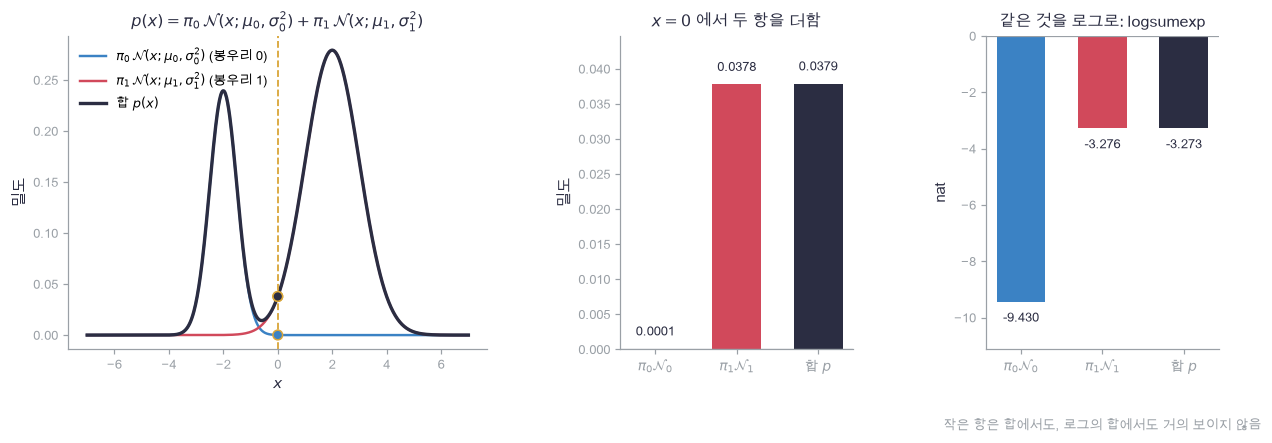

In [5]:
plot_marginal_sum(mix_x, mix_weighted, mix_total, 0.0, mix_terms0, mix_logp0)

🔍 **확인** · 왼쪽에서 파랑·빨강이 $\pi_k$를 곱한 성분 밀도이고, 진회색이 그 **합**입니다. 합 곡선이 두 봉우리를 모두 가지는 것이 "$z$를 더해서 없앤" 결과입니다.
가운데 막대는 $x=0$에서 두 항과 합입니다. 왼쪽 항은 막대가 보이지 않을 만큼 작습니다. 오른쪽은 같은 세 값을 로그로 본 것입니다. 로그에서도 작은 항은 합에 거의 기여하지 않고, 합의 로그는 큰 항의 로그에 가깝습니다.
이것이 logsumexp가 "최댓값을 빼고 계산해도 되는" 이유입니다.

### 🔍 같은 식을 2차원에서 보면

성분이 2차원 Gaussian이어도 식은 그대로입니다. $\mathcal N(x;\mu_k,\Sigma_k)$의 로그 밀도는 12번 2절의 세 항이고, 그 위에 $\pi_k$를 곱해 더합니다.
아래는 격자 위에서 성분 두 개와 그 합을 그린 것입니다.

> **코드** · `np.meshgrid(a, b)`: 두 축의 값 목록에서 격자 좌표 판 두 개를 만듭니다. `np.column_stack([xx.ravel(), yy.ravel()])`로 `(격자 수, 2)` 점 목록이 됩니다(12번 2절).

In [6]:
# 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀)
mix2_x0, mix2_x1 = np.meshgrid(np.linspace(-5, 5, 161), np.linspace(-4, 4, 161))   # (161, 161) 둘: 2차원 격자
mix2_points = np.column_stack([mix2_x0.ravel(), mix2_x1.ravel()])    # (161², 2): 격자를 점 목록으로
mix2_grids = []                                                      # 성분마다 π_k N(x; μ_k, Σ_k) 격자
for k in range(2):
    difference = mix2_points - MIX2_MU[k]                            # (161², 2): x − μ_k
    squared = np.sum(difference * np.linalg.solve(MIX2_COV[k], difference.T).T, axis=1)   # (161²,): (x−μ)ᵀΣ⁻¹(x−μ) (12번 2절)
    density = np.exp(-0.5 * squared) / (2 * np.pi * np.sqrt(np.linalg.det(MIX2_COV[k])))  # (161²,): 2차원 Gaussian 밀도
    mix2_grids.append((MIX2_PI[k] * density).reshape(mix2_x0.shape))
mix2_total = mix2_grids[0] + mix2_grids[1]                           # (161, 161): 두 성분을 더한 p(x)
mix2_area = (10 / 160) * (8 / 160)                                   # 격자 칸 하나의 넓이 (가로 간격 × 세로 간격)
print("2차원 격자 합 × 칸 넓이 =", round(float(mix2_total.sum() * mix2_area), 4), "(1 에 가까워야 합니다)")

2차원 격자 합 × 칸 넓이 = 0.9998 (1 에 가까워야 합니다)


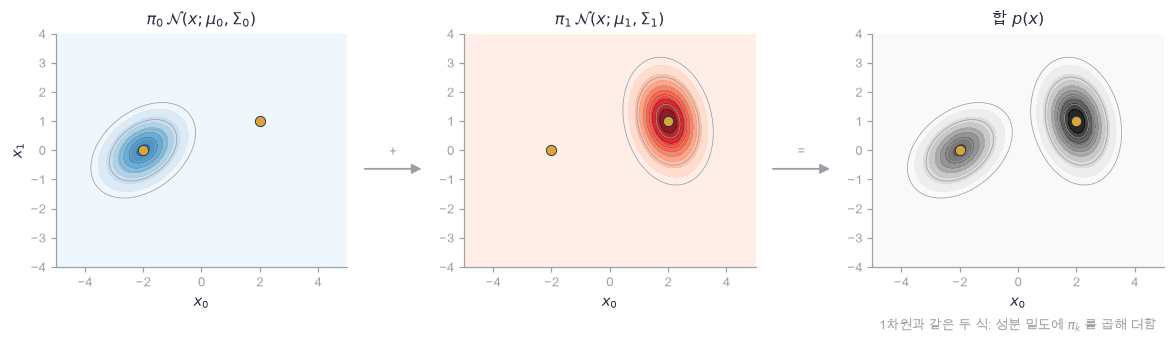

In [7]:
plot_mixture2_density(mix2_x0, mix2_x1, mix2_grids, mix2_total, MIX2_MU)

🔍 **확인** · 왼쪽 두 판이 $\pi_k$를 곱한 성분 밀도이고 오른쪽이 그 합입니다. 금색 점은 성분 평균 $\mu_k$입니다. 1차원과 달라진 것은 "제곱 거리"가 $\Sigma_k^{-1}$로 재는 거리가 된 것뿐이고, **더해서 없애는 구조는 같습니다.**
아래 구현은 이 두 식을 로그로 옮긴 것입니다. 로그 항을 만드는 함수와 그 항들을 안정적으로 더하는 함수를 따로 둡니다. 2절부터 5절까지 계속 이 둘을 씁니다.

In [8]:
def component_log_terms(x, pi, mu, sigma):
    """성분마다 log π_k + log N(x; μ_k, σ_k²) (합 안에 들어가는 항 t_nk).
    x: (N,), pi·mu·sigma: (K,) → (N, K)."""
    variance = sigma ** 2                                            # (K,): σ_k²
    return np.log(pi) - 0.5 * (np.log(2 * np.pi * variance) + (x[:, None] - mu) ** 2 / variance)


def logsumexp_rows(terms):
    """행마다 log Σ_k exp(t_nk). 최댓값을 빼고 지수합의 로그를 구한 뒤 다시 더합니다(02번 8절의 안정화).
    terms: (N, K) → (N,)."""
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]

In [9]:
def mix_logpdf(x, sigma=0.0):
    """두 봉우리 혼합의 log p(x) = logsumexp_k [log π_k + log N(x; μ_k, σ_k² + σ²)].
    sigma 는 5절에서 더하는 잡음의 표준편차입니다(0이면 원래 혼합). x: (N,) → (N,)."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    return logsumexp_rows(component_log_terms(x, MIX_PI, MIX_MU, np.sqrt(MIX_SIGMA ** 2 + sigma ** 2)))

In [10]:
def component2_log_terms(X, pi, mu, cov):
    """2차원 성분 로그 항 log π_k + log N(x; μ_k, Σ_k) (12번 2절의 로그 밀도에 log π_k 를 더한 것).
    X: (N, 2), pi: (K,), mu: (K, 2), cov: (K, 2, 2) → (N, K)."""
    out = np.zeros((len(X), len(pi)))
    for k in range(len(pi)):
        difference = X - mu[k]                                       # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(cov[k], difference.T).T, axis=1)   # (N,): 표준화한 제곱 거리
        out[:, k] = np.log(pi[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(cov[k])[1] + squared)
    return out


def mix2_logpdf(X):
    """2차원 두 봉우리 혼합의 log p(x). 1차원과 같은 식이고 성분 로그 항만 2차원 것입니다. X: (N, 2) → (N,)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀)
    return logsumexp_rows(component2_log_terms(X, MIX2_PI, MIX2_MU, MIX2_COV))

In [11]:
# 쓰는 것: mix_x, mix_total, mix_terms0, mix_logp0 (1절 계산 셀) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
np.testing.assert_allclose(mix_logpdf(mix_x), np.log(mix_total))                  # 검산: 로그 경로 = 그림의 선형 경로
np.testing.assert_allclose(mix_logpdf(np.array([0.0])), [mix_logp0])              # 검산: x = 0 의 두 항을 더한 값
np.testing.assert_allclose(mix_logpdf(np.array([0.0])), [-3.273491], atol=1e-6)   # 검산: 손계산 log p(0) = −3.273491
integral_x = np.linspace(-15, 15, 30001)                                          # 꼬리까지 넓은 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(integral_x)), integral_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
far_x = np.array([-40.0, 40.0])                                                   # 봉우리에서 아주 먼 두 점
naive_far = np.sum(MIX_PI * np.exp(-0.5 * (far_x[:, None] - MIX_MU) ** 2 / MIX_SIGMA ** 2) / np.sqrt(2 * np.pi * MIX_SIGMA ** 2), axis=1)
assert naive_far[0] == 0.0, "밀도를 그대로 더하면 x = −40 에서 0 으로 사라져야 합니다(언더플로)"
assert np.all(np.isfinite(mix_logpdf(far_x))), "logsumexp 경로는 같은 자리에서 유한한 값을 내야 합니다"
print("적분 1 · log p(0) =", round(float(mix_logpdf(np.array([0.0]))[0]), 6), "· x = ±40 의 log p =", mix_logpdf(far_x).round(2))

적분 1 · log p(0) = -3.273491 · x = ±40 의 log p = [-883.28 -723.28]


In [12]:
# 쓰는 것: mix2_points, mix2_total, mix2_area (1절 2차원 계산 셀)
np.testing.assert_allclose(np.exp(mix2_logpdf(mix2_points)), mix2_total.ravel(), atol=1e-14)   # 검산: 2차원도 로그 경로 = 그림의 선형 경로
mix2_integral = float(np.exp(mix2_logpdf(mix2_points)).sum() * mix2_area)
assert abs(mix2_integral - 1.0) < 0.01, "2차원 밀도의 격자 합 × 칸 넓이가 1 에서 0.01 안이어야 합니다"
print("2차원 격자 적분", round(mix2_integral, 4))

2차원 격자 적분 0.9998


🔍 **확인** · 세 가지가 맞았습니다. (1) 로그로 계산한 밀도가 그림에서 선형으로 더한 밀도와 같습니다. (2) 격자 적분이 1입니다. (3) $x=\pm40$처럼 먼 자리에서 밀도를 그대로 더하면 0으로 사라지지만(왼쪽은 정확히 `0.0`), logsumexp 경로는 $-883.28$ 같은 유한한 로그 값을 그대로 냅니다.
34번에서 잡음을 크게 더한 분포를 다룰 때 이 안정화가 없으면 손실이 `inf`가 됩니다.

### ✏️ 연습 1 · 행마다 안전하게 더하기(logsumexp)

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

성분 로그 항 `terms` `(N, K)`에서 행마다 $\log\sum_ke^{t_{nk}}$를 만듭니다. 최댓값을 빼는 줄은 써 두었으니 "뺀 지수의 행 합 → 로그 → 최댓값을 다시 더함" 한 줄을 채우세요. 검사는 손계산 두 줄과, 항이 $-800$처럼 작아도 결과가 유한한지를 봅니다.

In [13]:

def exercise_logsumexp(terms):
    """연습 1: 행마다 log Σ_k exp(t_nk) 를 최댓값을 빼고 계산합니다. terms: (N, K) → (N,)."""
    assert terms.ndim == 2, "성분 로그 항은 (N, K) 2차원이어야 합니다"
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: total = 최댓값을 뺀 지수의 행 합에 로그를 씌우고 최댓값을 다시 더한 (N,) 배열
    ### 힌트: 1절 logsumexp_rows 의 한 줄입니다. keepdims=True 로 더한 뒤 [:, 0] 으로 (N,) 을 꺼냅니다.
    raise NotImplementedError
    return total

In [14]:

def check_logsumexp(candidate):
    """손계산 두 줄과 아주 작은 항, 그리고 1절 mix_logpdf 와 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_x (1절 계산 셀) · component_log_terms, logsumexp_rows, mix_logpdf (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    example = np.array([[0., 0.], [1., 3.]])                         # (2, 2): 손계산용 로그 항
    actual = candidate(example)
    assert actual.shape == (2,), f"행마다 값 하나이므로 (2,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [np.log(2.), 3. + np.log(1. + np.exp(-2.))])   # 검산: log(1+1) 과 3 + log(1 + e^−2)
    tiny = np.array([[-800., -700.]])                                # 두 항 모두 exp 로는 0 이 되는 크기
    assert np.isfinite(candidate(tiny)[0]), "항이 −800 이어도 결과는 유한해야 합니다"
    np.testing.assert_allclose(candidate(tiny), [-700. + np.log(1. + np.exp(-100.))])  # 검산: 큰 항 + log(1 + e^−100)
    grid_terms = component_log_terms(mix_x, MIX_PI, MIX_MU, MIX_SIGMA)
    np.testing.assert_allclose(candidate(grid_terms), mix_logpdf(mix_x))              # 검산: 1절의 격자 로그 밀도와 같음
    print("logsumexp: 손계산·1절 밀도와 일치합니다.")

run_check(check_logsumexp, exercise_logsumexp, hint="total = (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]")

☐ exercise_logsumexp: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: total = (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
total = (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]
```

</details>

## 🔑 2. 거꾸로 묻기: 이 점은 어느 봉우리에서 왔나

**이 절에서 가져갈 것:** $z$를 되묻는 답은 Bayes 규칙이고, **분모가 바로 1절의 주변 밀도**입니다. $r_k(x)=\pi_k\mathcal N(x;\mu_k,\sigma_k^2)/p(x)$이며, 로그로 보면 같은 성분 로그 항의 softmax입니다.

1절은 "봉우리를 고른 뒤 점을 뽑는" 방향이었습니다. 이제 점 하나를 손에 들고 거꾸로 묻습니다. "$x=0$인 이 점은 왼쪽에서 왔을까 오른쪽에서 왔을까?"
답은 확률입니다. 두 경우의 밀도를 견주어 비율로 나누면 됩니다. 나누는 기준이 두 경우를 모두 더한 값, 곧 $p(x)$입니다.

> **용어**
>
> - **사후확률(posterior)** $p(z\mid x)$: 관측을 보고 난 뒤의 잠재변수 확률. 관측 전의 확률 $\pi_k$가 **사전확률(prior)** 입니다.
> - **책임확률(responsibility)** $r_k(x)$: 성분 $k$가 이 점을 "얼마나 책임지는가". 사후확률 $p(z=k\mid x)$의 다른 이름이고, 4절 학습에서 가중치로 쓰이기 때문에 이렇게 부릅니다. 코드에서는 `(N, K)` 배열이고 행 합이 1입니다.

Bayes 규칙 $p(z\mid x)=p(z)p(x\mid z)/p(x)$에 1절의 분모를 넣으면 **인덱스 식**은

$$r_k(x)=\frac{\pi_k\,\mathcal N(x;\mu_k,\sigma_k^2)}{\sum_{j}\pi_j\,\mathcal N(x;\mu_j,\sigma_j^2)},\qquad \sum_k r_k(x)=1.$$

로그 항 $t_{nk}$로 쓰면 분자와 분모가 모두 지수이므로 **배열 식**은 행마다의 softmax입니다.

$$r_{nk}=\frac{e^{t_{nk}}}{\sum_j e^{t_{nj}}}=\mathrm{softmax}_k(t_{n\cdot}),\qquad t:(N,K)\to r:(N,K).$$

1절의 logsumexp와 분모가 같습니다. 두 계산은 같은 판 $t$에서 나오는 형제입니다.

**손계산** $x=0$: 두 항이 $0.0000803$과 $0.037794$였으므로 $r_0(0)=0.0000803/0.037874=0.002120$, $r_1(0)=0.997880$입니다. $x=0$은 오른쪽 봉우리에서 왔을 확률이 99.8%입니다.

📎 두 성분의 로그 항 차 $t_0-t_1$은 $x$의 **이차식**입니다($\sigma_0\neq\sigma_1$이라 $x^2$ 계수가 남습니다). 그래서 $r_0=r_1$인 자리가 둘이고, 좁은 왼쪽 성분은 그 사이 구간에서만 이깁니다. 두 성분의 표준편차가 같으면 $x^2$이 지워져 경계가 하나입니다(03번 1절의 결정 경계).

> **코드**
>
> - `np.roots([a, b, c])`: 다항식 $ax^2+bx+c$의 근을 돌려줍니다. 여기서는 $t_0-t_1=0$인 두 자리를 닫힌식으로 얻는 데 씁니다.
> - `np.sign(v)`, `np.diff(v)`: 부호와 이웃 차이. 격자에서 곡선 두 개가 만나는 칸을 찾는 데 씁니다.
> - `np.maximum(a, 0.1)`: 원소마다 0.1 과 비교해 큰 쪽. 표준편차에 하한을 두어 항상 흰 화소에서 0으로 나누는 일을 막습니다.

In [15]:
# 쓰는 것: mix_x, mix_weighted, mix_total, mix_terms0 (1절 계산 셀) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
resp_curve = mix_weighted / mix_total[:, None]                       # (701, 2): r_k(x) = π_k N_k(x) / p(x)
resp_at0 = mix_terms0 / mix_terms0.sum()                             # (2,): x = 0 의 책임확률
resp_a = -0.5 / MIX_SIGMA[0] ** 2 + 0.5 / MIX_SIGMA[1] ** 2          # t_0 − t_1 의 x² 계수
resp_b = MIX_MU[0] / MIX_SIGMA[0] ** 2 - MIX_MU[1] / MIX_SIGMA[1] ** 2   # x 계수
resp_c = (-0.5 * MIX_MU[0] ** 2 / MIX_SIGMA[0] ** 2 + 0.5 * MIX_MU[1] ** 2 / MIX_SIGMA[1] ** 2
          + np.log(MIX_PI[0] / MIX_PI[1]) - np.log(MIX_SIGMA[0] / MIX_SIGMA[1]))                 # 상수 항
resp_boundaries = np.sort(np.roots([resp_a, resp_b, resp_c]))        # (2,): r_0 = r_1 인 두 자리
print("x = 0 의 책임확률", resp_at0.round(6), "· 행 합", round(float(resp_at0.sum()), 12))
print("이차식 계수", round(resp_a, 4), round(resp_b, 4), round(resp_c, 4), "· 경계", resp_boundaries.round(4))

x = 0 의 책임확률 [0.00212 0.99788] · 행 합 1.0
이차식 계수 -1.5 -10.0 -6.1542 · 경계 [-5.9807 -0.686 ]


In [16]:
# 쓰는 것: mnist_X, mnist_y, mnist_7 (📎 데이터 셀)
mnist_pi = np.bincount(mnist_y, minlength=10) / len(mnist_y)         # (10,): 사전확률 π_c = 그 숫자가 나온 비율
mnist_mu = np.stack([mnist_X[mnist_y == c].mean(axis=0) for c in range(10)])           # (10, 784): 숫자별 평균 이미지 (12번 4절)
mnist_sigma = np.maximum(np.stack([mnist_X[mnist_y == c].std(axis=0) for c in range(10)]), 0.1)   # (10, 784): 표준편차, 하한 0.1
mnist_squared = (mnist_7 - mnist_mu) ** 2 / mnist_sigma ** 2         # (10, 784): 화소마다 표준화한 제곱 거리
mnist_log_terms = np.log(mnist_pi) - 0.5 * np.sum(np.log(2 * np.pi * mnist_sigma ** 2) + mnist_squared, axis=1)   # (10,): 성분 로그 항
mnist_relative = mnist_log_terms - mnist_log_terms.max()             # (10,): 최댓값을 뺀 로그 항 (그림용)
mnist_resp = np.exp(mnist_relative) / np.exp(mnist_relative).sum()   # (10,): 책임확률
print("예시 7 의 로그 항 − 최댓값\n", mnist_relative.round(1))
print("책임확률", mnist_resp.round(4), "· 가장 큰 성분", int(mnist_resp.argmax()))

예시 7 의 로그 항 − 최댓값
 [-600.2 -308.1 -405.5 -256.3 -183.1 -197.  -374.8    0.  -225.3  -29.5]
책임확률 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] · 가장 큰 성분 7


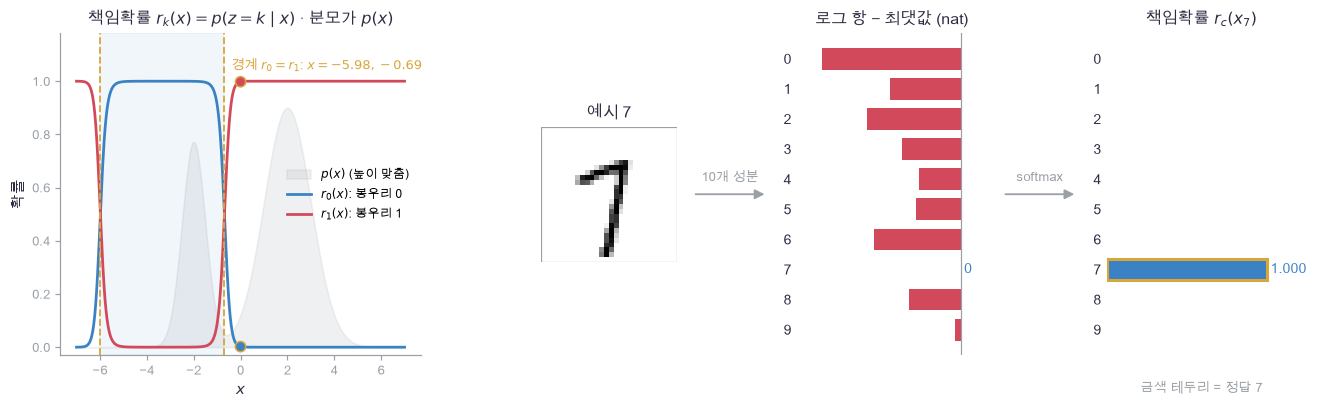

In [17]:
plot_responsibility(mix_x, resp_curve, mix_total, resp_boundaries, 0.0, resp_at0,
                    mnist_examples[7], mnist_relative, mnist_resp, 7)

🔍 **확인** · 왼쪽에서 $r_0$(파랑)와 $r_1$(빨강)은 어디서나 더해서 1입니다. 옅은 파랑 구간이 좁은 왼쪽 성분이 이기는 곳이고, 금색 점선 두 개가 이차식의 근 $x\approx-5.98,\ -0.69$입니다.
왼쪽 끝($x<-5.98$)에서 다시 빨강이 이기는 것이 재미있습니다. 표준편차가 큰 성분은 꼬리가 두꺼워서 **아주 먼 점은 오히려 넓은 성분에서 왔을 확률이 큽니다.**
오른쪽은 MNIST입니다. 예시 7의 화소 784개를 숫자별 Gaussian에 넣으면 로그 항이 숫자 7에서 가장 크고, 두 번째인 9와도 29 nat 차이입니다. softmax를 지나면 책임확률은 사실상 1과 0이 됩니다. **차원이 높으면 사후확률이 0 아니면 1로 몰립니다.**

In [18]:
def softmax_rows(terms):
    """행마다 softmax: 최댓값을 뺀 지수를 행 합으로 나눕니다(02번 8절). terms: (N, K) → (N, K), 행 합 1."""
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, K): 최댓값을 빼도 비율은 그대로
    return shifted / shifted.sum(axis=1, keepdims=True)

In [19]:
def mix_responsibility(x, sigma=0.0):
    """두 봉우리 혼합의 책임확률 r_k(x) = p(z = k | x) = softmax_k(로그 항).
    sigma 는 5절에서 더하는 잡음의 표준편차입니다. x: (N,) → (N, 2), 행 합 1."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · component_log_terms (1절)
    return softmax_rows(component_log_terms(x, MIX_PI, MIX_MU, np.sqrt(MIX_SIGMA ** 2 + sigma ** 2)))


def mix2_responsibility(X):
    """2차원 혼합의 책임확률. 1차원과 같은 softmax 이고 로그 항만 2차원 것입니다. X: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀) · component2_log_terms (1절)
    return softmax_rows(component2_log_terms(X, MIX2_PI, MIX2_MU, MIX2_COV))

In [20]:
# 쓰는 것: mix_x, resp_curve, resp_at0, resp_boundaries (2절 계산 셀) · mix2_points (1절 2차원 계산 셀)
np.testing.assert_allclose(mix_responsibility(mix_x), resp_curve)                 # 검산: softmax 경로 = 그림의 나눗셈 경로
np.testing.assert_allclose(mix_responsibility(mix_x).sum(axis=1), 1.0)            # 검산: 행 합 = 1
np.testing.assert_allclose(mix_responsibility(np.array([0.0])), [[0.002120, 0.997880]], atol=1e-6)   # 검산: 손계산 r(0)
sign_change = np.where(np.diff(np.sign(resp_curve[:, 0] - resp_curve[:, 1])))[0]  # 격자에서 두 곡선이 만나는 칸
crossing = mix_x[sign_change] + 0.5 * (mix_x[1] - mix_x[0])                       # 칸의 가운데를 경계로 봄
np.testing.assert_allclose(crossing, resp_boundaries, atol=0.011)                 # 검산: 격자 교차 = 이차식의 두 근
np.testing.assert_allclose(mix2_responsibility(mix2_points).sum(axis=1), 1.0)     # 검산: 2차원도 행 합 = 1
print("r(0) =", mix_responsibility(np.array([0.0]))[0], "· 격자 교차", crossing.round(4), "· 닫힌식 근", resp_boundaries.round(4))

r(0) = [0.00212 0.99788] · 격자 교차 [-5.99 -0.69] · 닫힌식 근 [-5.9807 -0.686 ]


In [21]:
# 쓰는 것: mnist_pi, mnist_mu, mnist_sigma, mnist_log_terms, mnist_resp (2절 MNIST 셀) · mnist_examples, mnist_labels (📎 데이터 셀)
np.testing.assert_allclose(softmax_rows(mnist_log_terms[None, :])[0], mnist_resp)   # 검산: 같은 softmax 가 10성분에도 그대로
mnist_all_squared = (mnist_examples.reshape(10, 1, 784) - mnist_mu) ** 2 / mnist_sigma ** 2      # (10, 10, 784): 예시마다 성분마다
mnist_all_terms = np.log(mnist_pi) - 0.5 * np.sum(np.log(2 * np.pi * mnist_sigma ** 2) + mnist_all_squared, axis=2)   # (10, 10)
mnist_guess = softmax_rows(mnist_all_terms).argmax(axis=1)                          # (10,): 예시마다 가장 큰 책임확률의 숫자
matched = int(np.sum(mnist_guess == mnist_labels))
assert matched >= 9, "고정 예시 10장 중 9장 이상에서 가장 큰 책임확률이 정답 숫자여야 합니다"
print("예시 10장의 추측", mnist_guess, "· 정답", mnist_labels, "· 맞은 수", matched)

예시 10장의 추측 [0 1 2 3 4 3 6 7 8 9] · 정답 [0 1 2 3 4 5 6 7 8 9] · 맞은 수 9


🔍 **확인** · 나눗셈 경로와 softmax 경로가 같고, 격자에서 찾은 교차 자리가 이차식의 근과 0.011 안에서 같습니다. 손계산 $r(0)=(0.002120,\,0.997880)$도 맞습니다.
MNIST에서는 고정 예시 10장 중 9장이 자기 숫자를 가장 크게 받았습니다. 틀린 한 장은 5를 3으로 봅니다. 화소를 서로 독립이라고 둔 대각 Gaussian이라 획의 **모양**이 아니라 "어느 화소가 켜지나"만 보기 때문입니다.
이것은 학습용 작은 문제이며 실제 숫자 분류기의 성능으로 읽지 마세요.

### ✏️ 연습 2 · 로그 항을 확률로 바꾸기(softmax)

성분 로그 항 `terms` `(N, K)`에서 행마다 softmax 를 만듭니다. 최댓값을 뺀 지수 `shifted` 는 써 두었으니 행 합으로 나누는 한 줄을 채우세요. 검사는 손계산 한 줄과 2절의 $r(0)$, 그리고 MNIST 10성분으로 합니다.

In [22]:

def exercise_softmax_rows(terms):
    """연습 2: 행마다 softmax 로 책임확률을 만듭니다. terms: (N, K) → (N, K), 행 합 1."""
    assert terms.ndim == 2, "성분 로그 항은 (N, K) 2차원이어야 합니다"
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, K): 최댓값을 빼도 비율은 그대로
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: r = shifted 를 행 합으로 나눈 (N, K) 배열
    ### 힌트: 2절 softmax_rows 의 한 줄입니다. 행 합은 keepdims=True 로 (N, 1) 을 유지해야 브로드캐스팅이 맞습니다.
    raise NotImplementedError
    return r

In [23]:

def check_softmax_rows(candidate):
    """손계산 한 줄과 2절의 r(0), MNIST 10성분 책임확률로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mnist_log_terms, mnist_resp (2절 MNIST 셀) · component_log_terms (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    example = np.array([[0., np.log(3.)]])                           # (1, 2): 두 항의 비가 1 : 3
    actual = candidate(example)
    assert actual.shape == (1, 2), f"책임확률은 로그 항과 같은 (1, 2) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [[0.25, 0.75]])                              # 검산: 1/(1+3) 과 3/(1+3)
    hand = candidate(component_log_terms(np.array([0.0]), MIX_PI, MIX_MU, MIX_SIGMA))
    np.testing.assert_allclose(hand, [[0.002120, 0.997880]], atol=1e-6)             # 검산: 2절 손계산 r(0)
    np.testing.assert_allclose(candidate(mnist_log_terms[None, :]), [mnist_resp])   # 검산: MNIST 10성분도 같은 한 줄
    print("softmax: 손계산·r(0)·MNIST 와 일치합니다.")

run_check(check_softmax_rows, exercise_softmax_rows, hint="r = shifted / shifted.sum(axis=1, keepdims=True)")

☐ exercise_softmax_rows: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: r = shifted / shifted.sum(axis=1, keepdims=True)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
r = shifted / shifted.sum(axis=1, keepdims=True)
```

</details>

## 🔑 3. 미분하면 책임확률이 가중치로 튀어나옵니다

**이 절에서 가져갈 것:** $\log p(x)$를 무엇으로 미분하든 결과는 **책임확률로 가중한 성분별 미분**입니다. 파라미터 쪽은 $\partial\log p/\partial\mu_k=r_k(x)(x-\mu_k)/\sigma_k^2$, 관측 쪽은 $\partial\log p/\partial x=\sum_kr_k(x)(\mu_k-x)/\sigma_k^2$이고 이것을 score라고 부릅니다.

로그 안에 합이 있으면 미분이 지저분해질 것 같습니다. 그런데 $\log$의 미분이 $1/p(x)$를 앞에 만들고, 그 $1/p(x)$가 2절의 **분모와 정확히 같습니다.** 그래서 미분마다 $r_k$가 저절로 나타납니다.

> **용어**
>
> - **score** $s(x)=\partial\log p(x)/\partial x$: 밀도의 로그를 **관측 $x$로** 미분한 것. "여기서 어느 쪽으로 가야 밀도가 커지나"를 가리키는 화살표입니다. 32번에서 신경망이 배우는 대상입니다.
> - **국소 미분(local derivative)**: 성분 하나만 있을 때의 미분. Gaussian 하나면 $\partial_x\log\mathcal N=(\mu-x)/\sigma^2$입니다.

$\log p(x)=\log\sum_j\pi_j\mathcal N_j(x)$를 $\mu_k$로 미분합니다. 합에서 $k$ 항만 살아남고, 앞에 $1/p(x)$가 붙습니다.

$$\frac{\partial\log p(x)}{\partial\mu_k}
=\frac{\pi_k\mathcal N_k(x)}{p(x)}\cdot\frac{x-\mu_k}{\sigma_k^2}
=r_k(x)\,\frac{x-\mu_k}{\sigma_k^2}.$$

같은 방법으로 $x$로 미분하면 모든 성분이 살아남아 가중합이 됩니다.

$$s(x)=\frac{\partial\log p(x)}{\partial x}=\sum_k r_k(x)\,\frac{\mu_k-x}{\sigma_k^2}
\quad\Longrightarrow\quad s(x)=-\sum_k\frac{\partial\log p(x)}{\partial\mu_k}.$$

$x$가 $(N,)$, $r$이 $(N,K)$, $\mu$가 $(K,)$이면 배열 식은 `np.sum(r * (mu - x[:, None]) / sigma ** 2, axis=1)`이고 결과는 $(N,)$입니다. 축 1(성분)을 더해 없앱니다.
표준편차로도 미분하면 $\partial\log p/\partial\sigma_k=r_k(x)\left[(x-\mu_k)^2/\sigma_k^3-1/\sigma_k\right]$입니다. 4절의 M 단계는 이 가운데 **파라미터 쪽 두 식**($\partial\log p/\partial\mu_k$와 $\partial\log p/\partial\sigma_k$, 그리고 합이 1이라는 제약을 붙인 $\pi_k$의 기울기)을 한 번에 0으로 만드는 자리를 찾습니다. score는 **관측 $x$로** 미분한 것이라 수렴한 뒤에도 0이 아닙니다(3절 그림의 화살표가 그것입니다).
2차원에서는 $1/\sigma_k^2$이 $\Sigma_k^{-1}$로 바뀌어 $\nabla_x\log p(x)=\sum_kr_k(x)\Sigma_k^{-1}(\mu_k-x)$가 됩니다.

**손계산** $x=0$: 2절의 $r(0)=(0.002120,\,0.997880)$을 식에 그대로 넣습니다.

$$s(0)=0.002120\cdot\frac{-2-0}{0.25}+0.997880\cdot\frac{2-0}{1}=-0.016961+1.995760=1.978799.$$

왼쪽 성분은 "왼쪽으로 가라"고 말하지만 가중치가 0.2%라 거의 들리지 않고, 오른쪽 성분의 말이 거의 그대로 답이 됩니다. 양수이므로 오른쪽 봉우리 쪽입니다.
파라미터 쪽은 $\partial\log p/\partial\mu_0=0.002120\cdot\frac{0-(-2)}{0.25}=0.016961$, $\partial\log p/\partial\mu_1=0.997880\cdot\frac{0-2}{1}=-1.995760$이고, 둘을 더하면 $-1.978799=-s(0)$입니다.

> **코드**
>
> - `np.linalg.solve(C, d.T).T`: 점마다 $C^{-1}d$를 한 번에 풉니다. 역행렬을 만들지 않는 쪽이 정확합니다(12번 2절).
> - `R[:, k:k + 1]`: `(N, K)`에서 성분 $k$의 열을 `(N, 1)`로 **모양을 유지한 채** 꺼냅니다. `R[:, k]`는 `(N,)`이라 열 방향 브로드캐스팅이 되지 않습니다.
> - `np.hypot(a, b)`: $\sqrt{a^2+b^2}$. 화살표의 길이를 잴 때 씁니다.

In [24]:
# 쓰는 것: resp_at0 (2절 계산 셀) · component_log_terms (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
score_arrow_x = np.linspace(-5, 5, 21)                               # (21,): 화살표를 그릴 자리
arrow_terms = np.exp(component_log_terms(score_arrow_x, MIX_PI, MIX_MU, MIX_SIGMA))   # (21, 2): 합 안의 항 π_k N(x; μ_k, σ_k²)
arrow_derivative = np.zeros(len(score_arrow_x))                      # (21,): 항을 하나씩 미분해 더한 p'(x)
for k in range(2):
    arrow_derivative += arrow_terms[:, k] * (MIX_MU[k] - score_arrow_x) / MIX_SIGMA[k] ** 2   # 항 하나의 미분
score_arrow = arrow_derivative / arrow_terms.sum(axis=1)             # (21,): p'(x)/p(x) 가 곧 score. 아래 구현과 다른 경로입니다
score_at0 = float(np.sum(resp_at0 * (MIX_MU - 0.0) / MIX_SIGMA ** 2))   # x = 0 의 score
score_dmu0 = resp_at0 * (0.0 - MIX_MU) / MIX_SIGMA ** 2              # (2,): x = 0 에서 μ_k 방향의 기울기
print("score(0) =", round(score_at0, 6), "· ∂log p/∂μ =", score_dmu0.round(6), "· 두 항의 합", round(float(score_dmu0.sum()), 6))

score(0) = 1.978799 · ∂log p/∂μ = [ 0.01696 -1.99576] · 두 항의 합 -1.978799


In [25]:
# 쓰는 것: mix2_x0, mix2_x1, mix2_points (1절 2차원 계산 셀) · mix2_logpdf (1절) · mix2_responsibility (2절) · MIX2_MU, MIX2_COV (📎 혼합 상수 셀)
field_logpdf = mix2_logpdf(mix2_points).reshape(mix2_x0.shape)       # (161, 161): 등고선용 log p
field_x, field_y = np.meshgrid(np.linspace(-4.5, 4.5, 13), np.linspace(-3.5, 3.5, 11))   # (11, 13) 둘: 화살표 자리
field_points = np.column_stack([field_x.ravel(), field_y.ravel()])   # (143, 2)
field_r = mix2_responsibility(field_points)                          # (143, 2): 자리마다 책임확률
field_score = np.zeros_like(field_points)                            # (143, 2): 성분 기여를 여기에 더합니다
for k in range(2):
    field_score += field_r[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - field_points).T).T   # r_k 로 가중한 Σ_k⁻¹(μ_k − x)
print("2차원 화살표", field_score.shape, "· 가장 긴 화살표", round(float(np.hypot(field_score[:, 0], field_score[:, 1]).max()), 3))

2차원 화살표 (143, 2) · 가장 긴 화살표 12.5


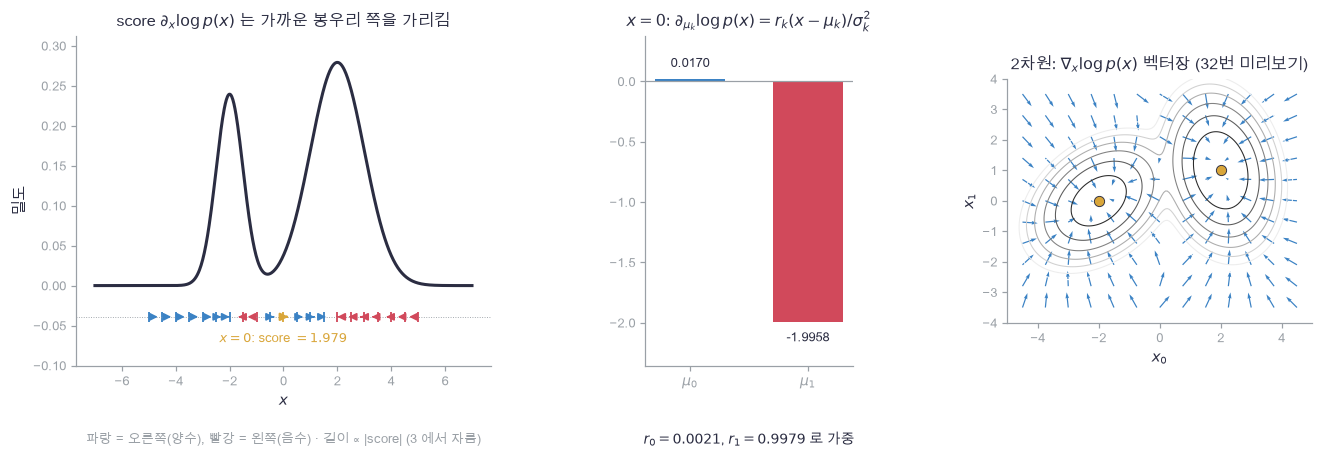

In [26]:
plot_score_field(mix_x, mix_total, score_arrow_x, score_arrow, 0.0, score_at0, score_dmu0, resp_at0,
                 mix2_x0, mix2_x1, field_logpdf, field_x, field_y,
                 field_score[:, 0].reshape(field_x.shape), field_score[:, 1].reshape(field_x.shape), MIX2_MU)

🔍 **확인** · 왼쪽 화살표는 자리마다의 score입니다. 봉우리 **바깥에서는 안쪽을 가리키고** 봉우리 위에서는 짧아집니다. 두 봉우리 사이에서 방향이 뒤집히는 자리가 밀도의 골짜기입니다.
가운데 막대는 $x=0$에서 $\mu_0,\mu_1$ 방향의 기울기입니다. $\mu_1$ 쪽이 압도적으로 큰 이유는 크기 $(x-\mu_k)/\sigma_k^2$가 아니라 **가중치 $r_k$** 때문입니다. $x=0$은 왼쪽 성분의 일이 아니라고 본 것입니다.
오른쪽은 2차원 벡터장입니다. 화살표가 등고선과 수직으로 봉우리를 향합니다. 32번은 이 벡터장을 신경망으로 배웁니다.

In [27]:
def mix_score(x, sigma=0.0):
    """혼합의 score s(x) = ∂ log p(x)/∂x = Σ_k r_k(x) (μ_k − x)/(σ_k² + σ²).
    sigma 는 5절에서 더하는 잡음의 표준편차입니다. x: (N,) → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · mix_responsibility (2절)
    variance = MIX_SIGMA ** 2 + sigma ** 2                           # (2,)
    return np.sum(mix_responsibility(x, sigma) * (MIX_MU - x[:, None]) / variance, axis=1)


def mix2_score(X):
    """2차원 혼합의 score ∇_x log p(x) = Σ_k r_k(x) Σ_k⁻¹(μ_k − x). X: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_MU, MIX2_COV (📎 혼합 상수 셀) · mix2_responsibility (2절)
    R = mix2_responsibility(X)                                       # (N, 2)
    S = np.zeros_like(X)
    for k in range(2):
        S += R[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T
    return S

In [28]:
def mix_mean_loglik(x, pi, mu, sigma):
    """관측의 평균 로그우도 (1/N) Σ_n log p(x_n). 4절의 EM 이 올리는 값입니다.
    x: (N,), pi·mu·sigma: (K,) → 숫자 하나."""
    # 쓰는 것: component_log_terms, logsumexp_rows (1절) · softmax_rows (2절)
    return logsumexp_rows(component_log_terms(x, pi, mu, sigma)).mean()


def mix_param_gradients(x, pi, mu, sigma):
    """평균 로그우도의 파라미터 기울기. ∂/∂μ_k = mean_n r_nk (x_n − μ_k)/σ_k²,
    ∂/∂σ_k = mean_n r_nk [(x_n − μ_k)²/σ_k³ − 1/σ_k]. x: (N,), pi·mu·sigma: (K,) → (dmu: (K,), dsigma: (K,))."""
    r = softmax_rows(component_log_terms(x, pi, mu, sigma))          # (N, K): 책임확률 (2절)
    difference = x[:, None] - mu                                     # (N, K): x_n − μ_k
    dmu = (r * difference / sigma ** 2).mean(axis=0)                 # (K,): 관측 축 평균
    dsigma = (r * (difference ** 2 / sigma ** 3 - 1 / sigma)).mean(axis=0)
    return dmu, dsigma

In [29]:
# 쓰는 것: score_arrow_x, score_arrow, score_at0 (3절 계산 셀) · field_points, field_score (3절 2차원 셀) · mix_logpdf (1절)
np.testing.assert_allclose(mix_score(score_arrow_x), score_arrow)                 # 검산: 구현 = 그림의 화살표
np.testing.assert_allclose(mix_score(np.array([0.0])), [1.978799], atol=1e-6)     # 검산: 손계산 s(0) = 1.978799
np.testing.assert_allclose(mix2_score(field_points), field_score)                 # 검산: 2차원도 그림과 같음
check_x = np.random.default_rng(2304).uniform(-6, 6, size=5)                      # (5,): 중심차분용 점 다섯 개


def logpdf_sum():
    """검사기용: 검사 점들의 log p 합. numerical_gradient 가 check_x 를 하나씩 흔듭니다."""
    return float(np.sum(mix_logpdf(check_x)))


score_error = rel_error(mix_score(check_x), numerical_gradient(logpdf_sum, check_x))
assert score_error < 1e-7, "score 와 중심차분의 상대오차가 1e−7 아래여야 합니다"
print("score 상대오차", score_error)

score 상대오차 7.6646192453406e-11


In [30]:
# 쓰는 것: mix_mean_loglik, mix_param_gradients, mix_score (3절) · score_dmu0 (3절 계산 셀) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
probe_x = np.random.default_rng(2305).normal(size=60) * 2            # (60,): 검사용 관측
probe_pi, probe_mu, probe_sigma = np.array([0.4, 0.6]), np.array([-1.5, 1.2]), np.array([0.8, 1.3])
probe_dmu, probe_dsigma = mix_param_gradients(probe_x, probe_pi, probe_mu, probe_sigma)


def mean_loglik_probe():
    """검사기용: probe 파라미터에서의 평균 로그우도. numerical_gradient 가 probe_mu·probe_sigma 를 흔듭니다."""
    return mix_mean_loglik(probe_x, probe_pi, probe_mu, probe_sigma)


param_errors = [rel_error(probe_dmu, numerical_gradient(mean_loglik_probe, probe_mu)),
                rel_error(probe_dsigma, numerical_gradient(mean_loglik_probe, probe_sigma))]
assert max(param_errors) < 1e-7, "μ·σ 기울기와 중심차분의 상대오차가 1e−7 아래여야 합니다"
single = np.array([0.0])                                             # 관측 하나면 평균이 그 값 자체
np.testing.assert_allclose(mix_param_gradients(single, MIX_PI, MIX_MU, MIX_SIGMA)[0], score_dmu0)   # 검산: 그림의 막대 두 개
np.testing.assert_allclose(mix_score(single), -np.sum(mix_param_gradients(single, MIX_PI, MIX_MU, MIX_SIGMA)[0]))   # 검산: s(x) = −Σ_k ∂log p/∂μ_k
print("μ 기울기 상대오차", param_errors[0], "· σ 기울기 상대오차", param_errors[1])

μ 기울기 상대오차 1.1269880872967291e-09 · σ 기울기 상대오차 9.415059790291452e-10


🔍 **확인** · score와 파라미터 기울기 모두 중심차분과 $10^{-7}$ 아래에서 같습니다. 손으로 유도한 "책임확률 가중합"이 맞다는 뜻입니다.
$s(x)=-\sum_k\partial\log p/\partial\mu_k$도 정확히 성립합니다. 평균을 오른쪽으로 옮기는 것과 점을 왼쪽으로 옮기는 것이 밀도에 같은 영향을 주기 때문입니다.

📎 32번은 이 score를 닫힌식 없이 **신경망으로** 배웁니다. 이 노트북의 `mix_score`가 그때 정답지가 됩니다. 34번은 아래 5절의 최적 복원과 score를 잇는 항등식을 씁니다.

### ✏️ 연습 3 · 책임확률로 가중한 score 한 줄

점 `x` `(N,)`와 그 자리의 책임확률 `R` `(N, 2)`에서 $s(x)=\sum_kr_k(x)(\mu_k-x)/\sigma_k^2$를 만듭니다. 성분 축을 더해 없애는 한 줄을 채우세요. 어느 축을 더하는지가 핵심입니다.

In [31]:

def exercise_mix_score(x, R):
    """연습 3: 책임확률로 가중한 1차원 혼합의 score. x: (N,), R: (N, 2) → (N,)."""
    assert R.shape == (len(x), 2), "책임확률은 (N, 2) 여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: s = R 로 가중한 성분별 기울기 (MIX_MU − x)/MIX_SIGMA² 를 성분 축에서 더한 (N,) 배열
    ### 힌트: 3절 `mix_score` 구현의 한 줄입니다. x 는 (N,) 이므로 x[:, None] 로 세워야 (N, 2) 와 브로드캐스팅됩니다. 더할 축은 1 입니다.
    raise NotImplementedError
    return s

In [32]:

def check_mix_score(candidate):
    """손계산 s(0) 과 3절 그림의 화살표, 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: score_arrow_x, score_arrow (3절 계산 셀) · mix_responsibility (2절) · mix_logpdf (1절)
    zero = np.array([0.0])
    actual = candidate(zero, mix_responsibility(zero))
    assert np.shape(actual) == (1,), f"점마다 값 하나이므로 (1,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [1.978799], atol=1e-6)                     # 검산: 3절 손계산 s(0)
    np.testing.assert_allclose(candidate(score_arrow_x, mix_responsibility(score_arrow_x)), score_arrow)   # 검산: 그림의 화살표
    local_x = np.random.default_rng(231).uniform(-5, 5, size=4)

    def local_logpdf_sum():
        """검사기용: 검사 점들의 log p 합."""
        return float(np.sum(mix_logpdf(local_x)))

    error = rel_error(candidate(local_x, mix_responsibility(local_x)), numerical_gradient(local_logpdf_sum, local_x))
    assert error < 1e-7, f"중심차분과의 상대오차 {error:.2e} 가 1e−7 아래여야 합니다"
    print("score: 손계산·화살표·중심차분과 일치합니다.")

run_check(check_mix_score, exercise_mix_score, hint="s = np.sum(R * (MIX_MU - x[:, None]) / MIX_SIGMA ** 2, axis=1)")

☐ exercise_mix_score: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: s = np.sum(R * (MIX_MU - x[:, None]) / MIX_SIGMA ** 2, axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
s = np.sum(R * (MIX_MU - x[:, None]) / MIX_SIGMA ** 2, axis=1)
```

</details>

## 🔑 4. EM: 책임확률로 가중해 평균을 다시 재는 반복

**이 절에서 가져갈 것:** $z$를 모르니 **부드럽게 나눠 가집니다.** E 단계는 2절의 책임확률을 구하고, M 단계는 그 $r$로 가중한 비율·평균·분산을 닫힌식으로 다시 잽니다. 이 반복에서 평균 로그우도는 **내려가지 않습니다.**

만약 각 점이 어느 봉우리에서 왔는지 안다면 학습은 쉽습니다. 봉우리별로 점을 모아 평균과 분산을 재면 끝입니다(12번 4절의 MLE).
모르니까 2절의 답을 씁니다. 점 하나를 $r_0$만큼 왼쪽 봉우리에, $r_1$만큼 오른쪽 봉우리에 나눠 넣습니다. 나눠 넣고 평균을 다시 재면 봉우리가 움직이고, 봉우리가 움직이면 나누는 비율이 또 달라집니다. 이 되먹임을 반복하는 것이 EM입니다.

> **용어**
>
> - **EM(expectation-maximization)**: 잠재변수가 있는 모형의 학습 방법. **E 단계**에서 잠재의 사후확률(책임확률)을 구하고, **M 단계**에서 그 확률로 가중한 우도를 최대화합니다.
> - **국소해(local optimum)**: 그 근처에서는 더 좋아질 수 없지만 전체 최선은 아닌 자리. EM은 시작값에 따라 다른 국소해로 갑니다.
> - **성분 번호 바꿔치기(label switching)**: 성분 0과 1의 번호를 서로 바꿔도 같은 분포라서 로그우도가 같은 현상. "성분 0이 무엇인지"는 데이터가 정해 주지 않습니다.

관측 $x$가 $(N,)$, 현재 파라미터가 $(K,)$ 세 개일 때 한 반복은 두 단계입니다.

$$\textbf{E 단계:}\quad r_{nk}=\frac{\pi_k\mathcal N(x_n;\mu_k,\sigma_k^2)}{\sum_j\pi_j\mathcal N(x_n;\mu_j,\sigma_j^2)}\ \ (N,K),
\qquad N_k=\sum_n r_{nk}\ \ (K,).$$

$$\textbf{M 단계:}\quad \pi_k\leftarrow\frac{N_k}{N},\qquad
\mu_k\leftarrow\frac{1}{N_k}\sum_n r_{nk}x_n,\qquad
\sigma_k^2\leftarrow\frac{1}{N_k}\sum_n r_{nk}(x_n-\mu_k)^2.$$

$N_k$는 "성분 $k$가 가져간 점의 수(소수도 가능)"입니다. 세 갱신은 12번 4절의 MLE 식에 가중치 $r_{nk}$가 붙은 것뿐입니다. 배열로는 `weight = R.sum(axis=0)`, `mu = (R * x[:, None]).sum(axis=0) / weight`처럼 **관측 축(0)** 을 더합니다.
M 단계의 결과는 3절의 파라미터 기울기를 0으로 만드는 자리입니다(단, 그 $r$을 고정했을 때). 그래서 EM이 수렴하면 3절의 $\partial\log p/\partial\mu_k$와 $\partial\log p/\partial\sigma_k$가 모두 0입니다.

**손계산** 관측 네 개 $x=(-2,-1,0,3)$, 시작값 $\pi=(0.5,0.5)$, $\mu=(-1,1)$, $\sigma=(1,1)$: 로그 항의 차가 $-2x$이므로 $r_0(x)=1/(1+e^{2x})$입니다.
$r_0=(0.982014,\,0.880797,\,0.5,\,0.002473)$이고 $N_0=2.365283$, 새 $\pi_0=N_0/4=0.591321$, 새 $\mu_0=(-2.837407)/2.365283=-1.199605$입니다. 왼쪽 봉우리가 왼쪽으로 끌려갔습니다.

> **코드**
>
> - `np.diff(values)`: 이웃한 값의 차이 `(T−1,)`. 로그우도가 내려가지 않았는지 볼 때 씁니다.
> - `values[::-1]`: 배열을 뒤집습니다. 성분 0과 1의 번호를 바꿔 보는 데 씁니다.
> - `np.einsum("nij,nj->ni", L, eps)`: 점마다 행렬 `L[n]` `(2, 2)`을 벡터 `eps[n]` `(2,)`에 곱합니다. 2차원 샘플을 만드는 12번 1절의 $\mu+L\epsilon$입니다.

In [33]:
# 쓰는 것: component_log_terms (1절) · softmax_rows (2절)
em_hand_x = np.array([-2., -1., 0., 3.])                             # (4,): 손계산용 관측 네 개
em_hand_pi, em_hand_mu, em_hand_sigma = np.array([0.5, 0.5]), np.array([-1., 1.]), np.array([1., 1.])
em_hand_r = softmax_rows(component_log_terms(em_hand_x, em_hand_pi, em_hand_mu, em_hand_sigma))   # (4, 2): E 단계
em_hand_weight = em_hand_r.sum(axis=0)                               # (2,): N_k = Σ_n r_nk
em_hand_mu_new = (em_hand_r * em_hand_x[:, None]).sum(axis=0) / em_hand_weight   # (2,): M 단계의 새 평균
print("r_0 =", em_hand_r[:, 0].round(6), "· N_k =", em_hand_weight.round(6))
print("새 π =", (em_hand_weight / 4).round(6), "· 새 μ =", em_hand_mu_new.round(6))

r_0 = [0.98201 0.8808  0.5     0.00247] · N_k = [2.36528 1.63472]
새 π = [0.59132 0.40868] · 새 μ = [-1.19961  1.73572]


In [34]:
# 쓰는 것: mix_x (1절 계산 셀) · component_log_terms, logsumexp_rows (1절) · softmax_rows (2절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
em_rng = np.random.default_rng(2301)
em_z = em_rng.choice(2, size=800, p=MIX_PI)                          # (800,): 잠재 성분. 아래 학습에서는 못 본 척합니다
em_data = MIX_MU[em_z] + MIX_SIGMA[em_z] * em_rng.normal(size=800)   # (800,): 관측만 남습니다
em_pi, em_mu, em_sigma = np.array([0.5, 0.5]), np.array([-0.5, 0.5]), np.array([1.0, 1.0])
em_loglik, em_snapshots = [], []
for iteration in range(40):
    terms_now = component_log_terms(em_data, em_pi, em_mu, em_sigma)             # 1. 이번 파라미터의 성분 로그 항
    em_loglik.append(logsumexp_rows(terms_now).mean())                           # 2. 갱신 전 평균 로그우도
    if iteration in (0, 2, 10):                                                  # 3. 그림에 쓸 성분 곡선
        weighted_now = np.exp(component_log_terms(mix_x, em_pi, em_mu, em_sigma))
        em_snapshots.append((iteration, weighted_now, weighted_now.sum(axis=1)))
    responsibility_now = softmax_rows(terms_now)                                 # 4. E 단계
    weight_now = responsibility_now.sum(axis=0)                                  # 5. M 단계: N_k
    em_pi = weight_now / len(em_data)
    em_mu = (responsibility_now * em_data[:, None]).sum(axis=0) / weight_now
    em_sigma = np.sqrt((responsibility_now * (em_data[:, None] - em_mu) ** 2).sum(axis=0) / weight_now)
print("EM 40 반복 · π", em_pi.round(4), "μ", em_mu.round(4), "σ", em_sigma.round(4))
print("참값       · π", MIX_PI, "μ", MIX_MU, "σ", MIX_SIGMA)
print("평균 로그우도", round(em_loglik[0], 5), "→", round(em_loglik[-1], 5))

EM 40 반복 · π [0.3084 0.6916] μ [-2.037   1.8633] σ [0.5094 1.0435]
참값       · π [0.3 0.7] μ [-2.  2.] σ [0.5 1. ]
평균 로그우도 -2.84929 → -1.84266


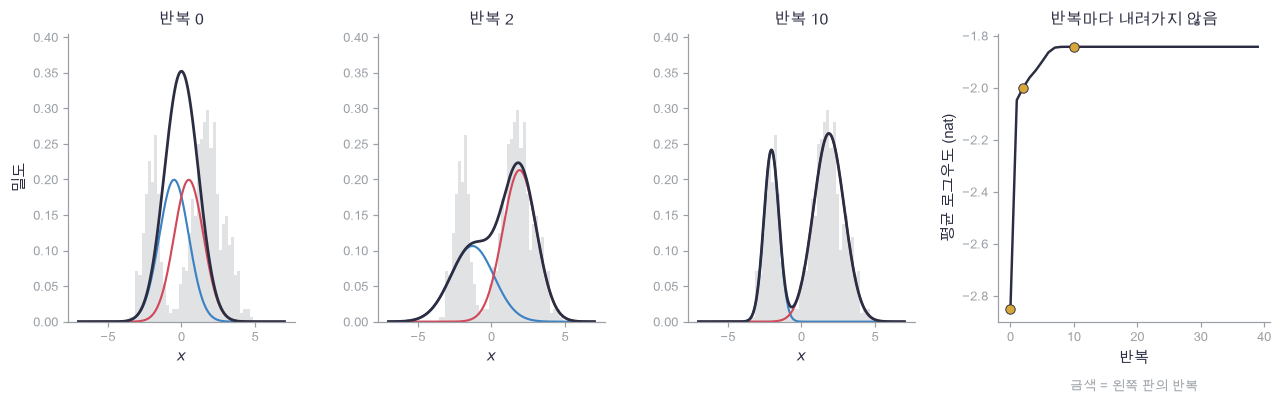

In [35]:
plot_em_progress(mix_x, em_data, em_snapshots, em_loglik)

🔍 **확인** · 반복 0에서는 두 성분이 거의 겹쳐 있어 합 곡선이 봉우리 하나입니다. 반복 2에서 오른쪽 성분이 오른쪽 덩어리를 가져가고, 반복 10에서는 이미 히스토그램의 두 봉우리를 각각 맡았습니다.
오른쪽 곡선은 평균 로그우도입니다. **한 번도 내려가지 않고** 빠르게 평평해집니다. 처음 몇 반복에서 대부분이 끝나는 것이 EM의 전형적인 모습입니다.
학습된 $\pi,\mu,\sigma$는 참값에 가깝지만 같지는 않습니다. 관측 800개에서 잰 값이라 표본 오차가 있습니다. 학습용 작은 문제의 결과입니다.

In [36]:
def em_step(x, pi, mu, sigma):
    """EM 한 반복. E 단계는 2절의 책임확률, M 단계는 r 로 가중한 비율·평균·분산의 닫힌식입니다.
    x: (N,), pi·mu·sigma: (K,) → (새 pi, 새 mu, 새 sigma, 갱신 전 파라미터의 평균 로그우도)."""
    # 쓰는 것: component_log_terms, logsumexp_rows (1절) · softmax_rows (2절)
    terms = component_log_terms(x, pi, mu, sigma)                    # (N, K)
    loglik = logsumexp_rows(terms).mean()                            # 갱신 전 평균 로그우도
    r = softmax_rows(terms)                                          # (N, K): E 단계
    weight = r.sum(axis=0)                                           # (K,): N_k = Σ_n r_nk
    mu_new = (r * x[:, None]).sum(axis=0) / weight                   # (K,): r 로 가중한 평균
    variance_new = (r * (x[:, None] - mu_new) ** 2).sum(axis=0) / weight   # (K,): 새 평균 기준의 가중 분산
    return weight / len(x), mu_new, np.sqrt(variance_new), loglik

In [37]:
# 쓰는 것: em_hand_x, em_hand_pi, em_hand_mu, em_hand_sigma, em_hand_weight (4절 손계산 셀)
hand_pi, hand_mu, hand_sigma, hand_loglik = em_step(em_hand_x, em_hand_pi, em_hand_mu, em_hand_sigma)
np.testing.assert_allclose(hand_pi, [0.591321, 0.408679], atol=1e-6)     # 검산: 손계산 π = N_k/4
np.testing.assert_allclose(hand_mu, [-1.199605, 1.735718], atol=1e-6)    # 검산: 손계산 μ
np.testing.assert_allclose(hand_pi, em_hand_weight / 4)                  # 검산: 위 셀의 N_k 와 같은 비율
print("한 반복 뒤 π", hand_pi.round(6), "μ", hand_mu.round(6), "σ", hand_sigma.round(6), "· 로그우도", round(hand_loglik, 6))

한 반복 뒤 π [0.59132 0.40868] μ [-1.19961  1.73572] σ [0.77682 1.61126] · 로그우도 -2.151911


In [38]:
# 쓰는 것: em_data, em_loglik, em_pi, em_mu, em_sigma (4절 학습 셀) · mix_param_gradients, mix_mean_loglik (3절)
step_pi, step_mu, step_sigma = np.array([0.5, 0.5]), np.array([-0.5, 0.5]), np.array([1.0, 1.0])
step_loglik = []
for _ in range(40):                                                  # 1. 같은 시작값에서 함수로 묶은 반복
    step_pi, step_mu, step_sigma, value = em_step(em_data, step_pi, step_mu, step_sigma)
    step_loglik.append(value)
np.testing.assert_allclose(step_loglik, em_loglik)                   # 검산: 함수 반복 = 위 셀의 손으로 쓴 반복
np.testing.assert_allclose(step_mu, em_mu)                           # 검산: 같은 파라미터에 도착
assert np.all(np.diff(em_loglik) >= -1e-12), "평균 로그우도는 반복마다 내려가지 않아야 합니다"
em_dmu, em_dsigma = mix_param_gradients(em_data, em_pi, em_mu, em_sigma)   # 2. 수렴점에서 3절의 기울기
assert max(np.abs(em_dmu).max(), np.abs(em_dsigma).max()) < 1e-8, "수렴점에서 μ·σ 기울기가 0 에 가까워야 합니다"
swapped = mix_mean_loglik(em_data, em_pi[::-1], em_mu[::-1], em_sigma[::-1])   # 3. 성분 번호만 바꿔 보기
np.testing.assert_allclose(swapped, mix_mean_loglik(em_data, em_pi, em_mu, em_sigma))   # 검산: label switching 은 로그우도를 바꾸지 않음
print("로그우도 최소 증가량", np.diff(em_loglik).min(), "· 수렴점 기울기 최대 크기", max(np.abs(em_dmu).max(), np.abs(em_dsigma).max()))
print("성분 번호를 바꾼 로그우도", round(swapped, 10), "= 원래", round(mix_mean_loglik(em_data, em_pi, em_mu, em_sigma), 10))

로그우도 최소 증가량 -8.881784197001252e-16 · 수렴점 기울기 최대 크기 1.5487611193520933e-15
성분 번호를 바꾼 로그우도 -1.8426634526 = 원래 -1.8426634526


🔍 **확인** · 세 가지가 확인되었습니다. (1) `em_step`을 40번 부른 결과가 위 셀의 손으로 쓴 반복과 완전히 같습니다. (2) 평균 로그우도의 최소 증가량이 $-10^{-12}$보다 크므로 한 번도 내려가지 않았습니다(부동소수점 오차 범위). (3) 수렴점에서 3절의 파라미터 기울기가 $10^{-8}$ 아래입니다. **M 단계의 닫힌식이 곧 기울기 0의 자리**라는 뜻입니다.
성분 번호를 바꿔도 로그우도가 소수점 10자리까지 같습니다. 그래서 "성분 0이 왼쪽"이라고 주장할 근거는 없습니다. 학습 결과를 참값과 비교할 때는 번호를 맞춰 보아야 합니다.

### 🔍 2차원에서 같은 두 단계

바뀌는 것은 M 단계의 분산이 **공분산 행렬**이 되는 것뿐입니다.

$$\Sigma_k\leftarrow\frac{1}{N_k}\sum_n r_{nk}(x_n-\mu_k)(x_n-\mu_k)^\top\quad(2,2).$$

$(x_n-\mu_k)$가 $(N,2)$이므로 `(R[:, k, None] * d).T @ d / weight[k]`가 위 합입니다. 아래는 같은 반복을 2차원 데이터에 돌린 것입니다.

In [39]:
def em2_step(X, pi, mu, cov):
    """2차원 EM 한 반복. M 단계의 분산이 가중 공분산 (1/N_k) Σ_n r_nk (x_n − μ_k)(x_n − μ_k)ᵀ 가 됩니다.
    X: (N, 2), pi: (K,), mu: (K, 2), cov: (K, 2, 2) → (새 pi, 새 mu, 새 cov, 갱신 전 평균 로그우도)."""
    # 쓰는 것: component2_log_terms, logsumexp_rows (1절) · softmax_rows (2절)
    terms = component2_log_terms(X, pi, mu, cov)                     # (N, K)
    loglik = logsumexp_rows(terms).mean()
    R = softmax_rows(terms)                                          # (N, K): E 단계
    weight = R.sum(axis=0)                                           # (K,): N_k
    mu_new = (R.T @ X) / weight[:, None]                             # (K, 2): r 로 가중한 평균
    cov_new = np.zeros_like(cov)
    for k in range(len(pi)):
        difference = X - mu_new[k]                                   # (N, 2)
        cov_new[k] = (R[:, k, None] * difference).T @ difference / weight[k]
    return weight / len(X), mu_new, cov_new, loglik

In [40]:
# 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀) · component2_log_terms (1절) · softmax_rows (2절)
em2_rng = np.random.default_rng(2302)
em2_z = em2_rng.choice(2, size=600, p=MIX2_PI)                       # (600,): 잠재 성분
em2_L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L Lᵀ (12번 1절)
em2_data = MIX2_MU[em2_z] + np.einsum("nij,nj->ni", em2_L[em2_z], em2_rng.normal(size=(600, 2)))   # (600, 2): μ_z + L_z ε
em2_pi, em2_mu = np.array([0.5, 0.5]), np.array([[-0.5, -0.5], [0.5, 0.5]])
em2_cov, em2_loglik, em2_snapshots = np.array([np.eye(2), np.eye(2)]), [], []
for iteration in range(31):
    if iteration in (0, 2, 10, 30):                                  # 그림용: 이번 파라미터와 책임확률
        em2_snapshots.append((iteration, em2_mu.copy(), em2_cov.copy(),
                              softmax_rows(component2_log_terms(em2_data, em2_pi, em2_mu, em2_cov))))
    em2_pi, em2_mu, em2_cov, em2_value = em2_step(em2_data, em2_pi, em2_mu, em2_cov)
    em2_loglik.append(em2_value)
assert np.all(np.diff(em2_loglik) >= -1e-12), "2차원에서도 평균 로그우도는 내려가지 않아야 합니다"
oracle_mu, oracle_cov = np.zeros_like(em2_mu), np.zeros_like(em2_cov)   # z 를 훔쳐보고 12번 4절의 MLE 로 잰 값
for k in range(2):
    group = em2_data[em2_z == k]                                     # 실제로 성분 k 에서 나온 점들
    oracle_mu[k] = group.mean(axis=0)
    oracle_cov[k] = (group - oracle_mu[k]).T @ (group - oracle_mu[k]) / len(group)
np.testing.assert_allclose(em2_mu, oracle_mu, atol=0.05)             # 검산: z 를 모르고 얻은 평균 ≈ z 를 알고 잰 평균
np.testing.assert_allclose(em2_cov, oracle_cov, atol=0.05)           # 검산: 공분산도 거의 같음
print("2차원 EM · π", em2_pi.round(3), "· μ\n", em2_mu.round(3), "\n· 성분 0 의 공분산\n", em2_cov[0].round(3))
print("z 를 훔쳐본 성분 0 의 공분산\n", oracle_cov[0].round(3), "· 참값\n", MIX2_COV[0])
print("평균 로그우도", round(em2_loglik[0], 4), "→", round(em2_loglik[-1], 4))

2차원 EM · π [0.424 0.576] · μ
 [[-2.077 -0.054]
 [ 2.053  0.948]] 
· 성분 0 의 공분산
 [[0.702 0.266]
 [0.266 0.527]]
z 를 훔쳐본 성분 0 의 공분산
 [[0.714 0.262]
 [0.262 0.522]] · 참값
 [[0.6 0.2]
 [0.2 0.5]]
평균 로그우도 -4.3281 → -2.926


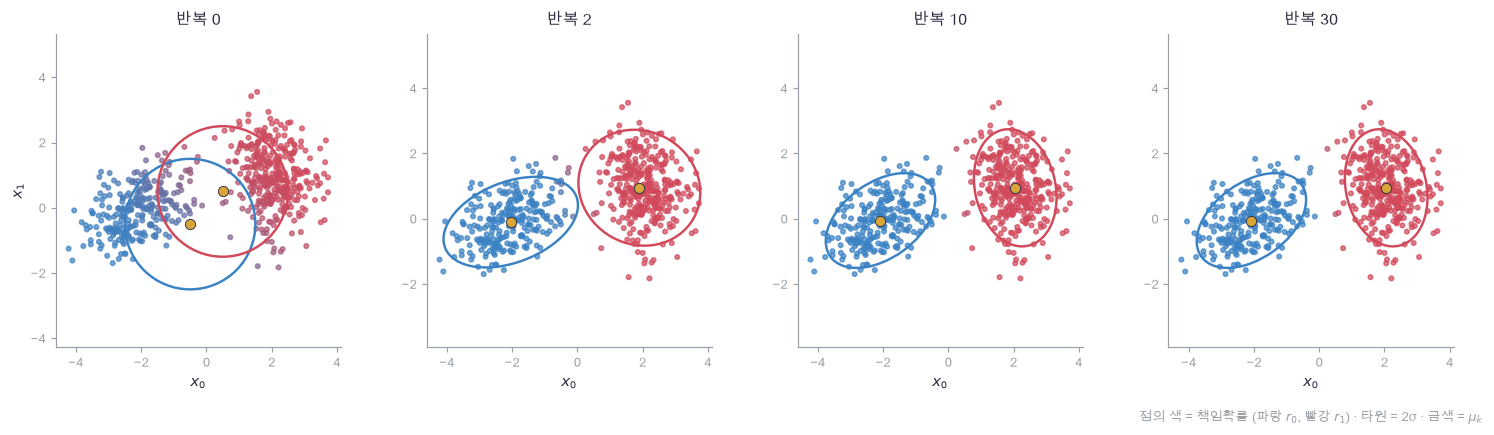

In [41]:
plot_em2_progress(em2_data, em2_snapshots)

🔍 **확인** · 점의 색이 책임확률입니다. 반복 0에서는 가운데 점들이 보라색(두 성분이 반씩 책임)이지만, 반복이 지나면 거의 모든 점이 파랑 또는 빨강으로 갈립니다.
타원은 성분 공분산의 $2\sigma$ 등고선입니다. 처음의 동그란 단위 원이 데이터의 기울기를 따라 기울어집니다.
검산이 재미있습니다. **$z$를 훔쳐보고** 성분별로 점을 모아 잰 평균·공분산(12번 4절의 MLE)과 EM이 $z$ 없이 얻은 값이 0.05 안에서 같습니다. 참값 $0.6$과의 차이($0.70$)는 EM의 잘못이 아니라 성분 0에서 실제로 나온 255개 점의 흔들림입니다.

### ✏️ 연습 4 · M 단계의 평균 갱신

책임확률 `R` `(N, K)`와 관측 `x` `(N,)`에서 $\mu_k=\frac{1}{N_k}\sum_nr_{nk}x_n$을 만듭니다. $N_k$를 담은 `weight` 는 써 두었으니 가중 평균 한 줄을 채우세요. 어느 축을 더하는지(관측 축 0)가 핵심입니다.

In [42]:

def exercise_m_step_mu(x, R):
    """연습 4: M 단계의 평균 갱신 μ_k = (Σ_n r_nk x_n) / N_k. x: (N,), R: (N, K) → (K,)."""
    assert len(R) == len(x), "책임확률의 행 수는 관측 수와 같아야 합니다"
    weight = R.sum(axis=0)                                           # (K,): N_k = 성분 k 가 가져간 점의 수
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: mu = r 로 가중한 x 의 합을 N_k 로 나눈 (K,) 배열
    ### 힌트: 4절 em_step 의 mu_new 한 줄입니다. x 는 (N,) 이므로 x[:, None] 로 세우고, 더할 축은 관측 축 0 입니다.
    raise NotImplementedError
    return mu

In [43]:

def check_m_step_mu(candidate):
    """4절 손계산 네 점과 em_step 의 결과로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: em_hand_x, em_hand_r, em_hand_mu_new (4절 손계산 셀) · em_data (4절 학습 셀) · em_step (4절) · component_log_terms (1절) · softmax_rows (2절)
    actual = candidate(em_hand_x, em_hand_r)
    assert np.shape(actual) == (2,), f"성분마다 평균 하나이므로 (2,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [-1.199605, 1.735718], atol=1e-6)   # 검산: 4절 손계산의 새 μ
    np.testing.assert_allclose(actual, em_hand_mu_new)                     # 검산: 손계산 셀의 값과 같음
    hard = np.array([[1., 0.], [1., 0.], [0., 1.]])                        # 책임확률이 0/1 이면 그냥 그룹 평균
    np.testing.assert_allclose(candidate(np.array([2., 4., 10.]), hard), [3., 10.])   # 검산: (2+4)/2 과 10/1
    start_pi, start_mu, start_sigma = np.array([0.5, 0.5]), np.array([-0.5, 0.5]), np.array([1.0, 1.0])
    start_r = softmax_rows(component_log_terms(em_data, start_pi, start_mu, start_sigma))   # 같은 시작값의 E 단계
    np.testing.assert_allclose(candidate(em_data, start_r), em_step(em_data, start_pi, start_mu, start_sigma)[1])   # 검산: em_step 한 반복의 새 μ
    print("M 단계의 평균: 손계산·em_step 과 일치합니다.")

run_check(check_m_step_mu, exercise_m_step_mu, hint="mu = (R * x[:, None]).sum(axis=0) / weight")

☐ exercise_m_step_mu: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mu = (R * x[:, None]).sum(axis=0) / weight


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mu = (R * x[:, None]).sum(axis=0) / weight
```

</details>

## 🔑 5. 잠재를 먼저 뽑고 관측을 뽑기

**이 절에서 가져갈 것:** 혼합에서 점을 만드는 방법은 밀도를 뒤집는 것이 아니라 **만든 순서를 그대로 따라가는 것**입니다. $z\sim\pi$를 뽑고 그 성분에서 $x\sim\mathcal N(\mu_z,\sigma_z^2)$를 뽑습니다. 이것을 ancestral sampling이라고 합니다.

1절에서 "봉우리를 고른 뒤 점을 뽑는다"고 말했습니다. 그 문장을 코드로 옮기면 그대로 샘플러입니다. 잠재변수 모형의 좋은 점이 여기 있습니다. 밀도는 복잡해도 **만드는 절차는 두 줄**입니다.

> **용어**
>
> - **ancestral sampling(조상 샘플링)**: 화살표 방향(원인 → 결과)을 따라 차례로 뽑는 방법. 여기서는 $z$를 먼저, $x$를 나중에 뽑습니다. 28번의 생성자, 34번의 잡음 과정도 같은 방식입니다.
> - **경험 분포(empirical distribution)**: 뽑은 표본이 만드는 히스토그램. 표본 수를 늘리면 밀도 곡선에 가까워집니다(02번 4절의 Monte Carlo).

$z_n\sim\mathrm{Categorical}(\pi)$, $x_n\mid z_n\sim\mathcal N(\mu_{z_n},\sigma_{z_n}^2)$입니다. 배열로는 $z$가 $(n,)$ 정수이고, `MIX_MU[z]`가 $(n,)$ 실수입니다. **정수 배열로 인덱싱**하면 점마다 자기 성분의 평균을 골라 옵니다.

$$x_n=\mu_{z_n}+\sigma_{z_n}\epsilon_n,\qquad \epsilon_n\sim\mathcal N(0,1).$$

닫힌식 검산에 쓸 두 값도 잠재로 조건을 걸어 얻습니다.

$$\mathbb E[x]=\sum_k\pi_k\mu_k=0.8,\qquad
\mathrm{Var}(x)=\sum_k\pi_k(\sigma_k^2+\mu_k^2)-\left(\sum_k\pi_k\mu_k\right)^2=4.135.$$

분산이 각 성분의 분산보다 훨씬 큰 이유는 "어느 봉우리인가"라는 **잠재의 흔들림**이 더해지기 때문입니다.

> **코드**
>
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 $n$번 뽑습니다. 잠재 $z$를 뽑는 줄입니다.
> - `MIX_MU[z]`: 정수 배열로 인덱싱. `z`가 `(n,)`이면 결과도 `(n,)`이고 $n$번째 값이 `MIX_MU[z[n]]`입니다(00b 4절).
> - `np.searchsorted(cumulative, u)`: 누적 확률 배열에서 $u$가 들어갈 자리를 찾습니다. `rng.choice` 없이 균등 난수만으로 성분을 고를 때 씁니다.

In [44]:
# 쓰는 것: mix_x (1절 계산 셀) · mix_logpdf (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
sample_rng = np.random.default_rng(2306)
sample_z = sample_rng.choice(2, size=4000, p=MIX_PI)                 # (4000,): 1. 잠재 성분 z ~ π
sample_x = MIX_MU[sample_z] + MIX_SIGMA[sample_z] * sample_rng.normal(size=4000)   # (4000,): 2. x ~ N(μ_z, σ_z²)
sample_density = np.exp(mix_logpdf(mix_x))                           # (701,): 1절의 밀도 곡선
sample_mean_closed = float(np.sum(MIX_PI * MIX_MU))                  # 닫힌식 평균
sample_var_closed = float(np.sum(MIX_PI * (MIX_SIGMA ** 2 + MIX_MU ** 2)) - sample_mean_closed ** 2)   # 닫힌식 분산
print("z = 0 의 비율", round(float((sample_z == 0).mean()), 4), "(π_0 = 0.3)")
print("표본 평균", round(float(sample_x.mean()), 4), "· 닫힌식", sample_mean_closed)
print("표본 분산", round(float(sample_x.var()), 4), "· 닫힌식", sample_var_closed)

z = 0 의 비율 0.3105 (π_0 = 0.3)
표본 평균 0.7536 · 닫힌식 0.7999999999999999
표본 분산 4.2049 · 닫힌식 4.135000000000001


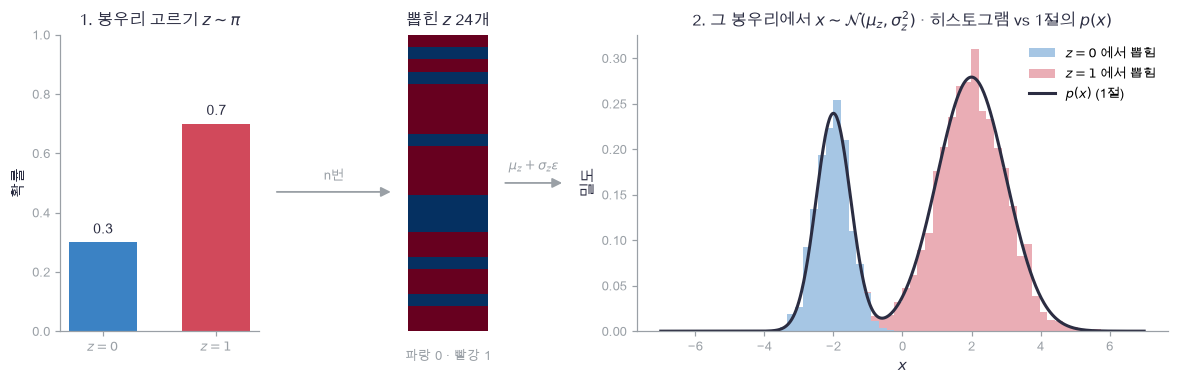

In [45]:
plot_ancestral_sampling(MIX_PI, sample_z[:24], sample_x, sample_z, mix_x, sample_density)

🔍 **확인** · 왼쪽 막대가 $\pi$이고, 가운데 띠가 실제로 뽑힌 $z$ 24개입니다(파랑 0, 빨강 1). 빨강이 더 자주 나오는 것이 $\pi_1=0.7$입니다.
오른쪽 히스토그램은 성분별로 색을 칠해 쌓은 것이고, 검은 곡선이 1절의 $p(x)$입니다. **두 성분의 히스토그램을 쌓은 것이 밀도 곡선과 겹칩니다.** 밀도의 합이 곧 "두 경우를 모두 세는 것"이었음을 눈으로 보는 그림입니다.

In [46]:
def mix_sample(n, rng):
    """ancestral sampling: z ~ π 를 뽑고 그 성분에서 x ~ N(μ_z, σ_z²) 를 뽑습니다.
    n: 개수, rng: np.random.default_rng(...) → (n,)."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 잠재 성분
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)


def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀)
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L Lᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], rng.normal(size=(n, 2)))

In [47]:
# 쓰는 것: sample_x, sample_mean_closed, sample_var_closed (5절 계산 셀) · MIX2_PI, MIX2_MU (📎 혼합 상수 셀)
np.testing.assert_allclose(mix_sample(4000, np.random.default_rng(2306)), sample_x)   # 검산: 같은 seed 면 위 두 줄과 같은 표본
assert abs(float(sample_x.mean()) - sample_mean_closed) < 0.12, "4,000개 표본 평균이 닫힌식 0.8 에서 0.12 안이어야 합니다"
assert abs(float(sample_x.var()) - sample_var_closed) < 0.5, "표본 분산이 닫힌식 4.135 에서 0.5 안이어야 합니다"
sample2 = mix2_sample(4000, np.random.default_rng(2309))             # (4000, 2)
mean2_closed = MIX2_PI @ MIX2_MU                                     # (2,): Σ_k π_k μ_k
np.testing.assert_allclose(sample2.mean(axis=0), mean2_closed, atol=0.15)   # 검산: 2차원 표본 평균 ≈ 닫힌식
print("2차원 표본 평균", sample2.mean(axis=0).round(4), "· 닫힌식", mean2_closed.round(4))

2차원 표본 평균 [0.4594 0.6146] · 닫힌식 [0.4 0.6]


### 🔑 잡음이 더해진 뒤의 최적 복원

**이 절에서 가져갈 것:** 관측에 Gaussian 잡음을 더해 $\tilde x=x+\sigma\epsilon$만 보게 되면, 원래 $x$의 최선의 추측은 $\mathbb E[x\mid\tilde x]$이고 이것도 **책임확률의 가중합**입니다. 단, 성분 분산이 $\sigma_k^2+\sigma^2$로 커진 책임확률입니다.

34·35번의 diffusion은 "잡음이 낀 이미지에서 원래 이미지를 추측하는" 문제를 반복해서 풉니다. 혼합에서는 그 답이 닫힌식이라 미리 확인해 둘 수 있습니다.

> **용어**
>
> - **최적 복원(denoiser)** $\mathbb E[x\mid\tilde x]$: 잡음 낀 관측 $\tilde x$를 보고 원래 값을 추측할 때, 제곱오차를 가장 작게 만드는 추측. 조건부 기댓값입니다(14번 1절의 "제곱오차의 최소는 평균").
> - **잡음 낀 분포** $q_\sigma(\tilde x)$: $x$에 표준편차 $\sigma$의 잡음을 더한 뒤의 분포. 혼합이면 성분 분산만 $\sigma_k^2+\sigma^2$로 커진 같은 꼴의 혼합입니다.

잠재 $z$와 잡음 $\epsilon$이 독립이므로 $\tilde x\mid z=k$는 $\mathcal N(\mu_k,\sigma_k^2+\sigma^2)$입니다. 그러니 잡음 뒤의 책임확률 $r_k^\sigma(\tilde x)$는 **분산만 바꾼 2절의 식**입니다.
성분 안에서는 두 Gaussian의 결합이라 조건부 평균이 닫힌식으로 나옵니다.

$$\mathbb E[x\mid\tilde x,z=k]=\mu_k+\frac{\sigma_k^2}{\sigma_k^2+\sigma^2}(\tilde x-\mu_k),\qquad
\mathbb E[x\mid\tilde x]=\sum_k r_k^\sigma(\tilde x)\left[\mu_k+\frac{\sigma_k^2}{\sigma_k^2+\sigma^2}(\tilde x-\mu_k)\right].$$

$\sigma\to0$이면 계수가 1이 되어 $\mathbb E[x\mid\tilde x]=\tilde x$(그대로 두기), $\sigma\to\infty$이면 계수가 0이고 $r^\sigma\to\pi$가 되어 전체 평균 $\sum_k\pi_k\mu_k=0.8$로 수축합니다.
2차원은 $\sigma_k^2/(\sigma_k^2+\sigma^2)$가 $\Sigma_k(\Sigma_k+\sigma^2I)^{-1}$로 바뀝니다.

**손계산** $\sigma=1$, $\tilde x=0$: 분산이 $(1.25,\,2)$이므로 두 항은 $0.021613$과 $0.072644$, 따라서 $r^\sigma=(0.229295,\,0.770705)$입니다.
성분별 조건부 평균은 $-2+\frac{0.25}{1.25}(0+2)=-1.6$과 $2+\frac{1}{2}(0-2)=1$이므로 $\mathbb E[x\mid\tilde x=0]=0.229295\times(-1.6)+0.770705\times1=0.403833$입니다.

In [48]:
# 쓰는 것: mix_x (1절 계산 셀) · component_log_terms, mix_logpdf (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
denoise_sigmas = [0.25, 1.0, 3.0]
denoise_curves = np.zeros((len(mix_x), 3))                           # (701, 3): σ 마다 E[x | x̃] 곡선
denoise_noisy = np.zeros((len(mix_x), 3))                            # (701, 3): σ 마다 잡음 낀 관측의 밀도 q_σ
for j, sigma in enumerate(denoise_sigmas):
    variance = MIX_SIGMA ** 2 + sigma ** 2                           # (2,): 잡음을 더한 성분 분산
    noisy_terms = np.exp(component_log_terms(mix_x, MIX_PI, MIX_MU, np.sqrt(variance)))   # (701, 2): π_k N(x̃; μ_k, σ_k² + σ²)
    noisy_resp = noisy_terms / noisy_terms.sum(axis=1, keepdims=True)   # (701, 2): 2절의 나눗셈 경로로 구한 r^σ
    conditional = MIX_MU + MIX_SIGMA ** 2 / variance * (mix_x[:, None] - MIX_MU)   # (701, 2): 성분별 조건부 평균
    denoise_curves[:, j] = np.sum(noisy_resp * conditional, axis=1)
    denoise_noisy[:, j] = np.exp(mix_logpdf(mix_x, sigma))
denoise_hand = float(denoise_curves[np.argmin(np.abs(mix_x)), 1])    # σ = 1, x̃ = 0 의 값
print("σ = 1, x̃ = 0 의 최적 복원", round(denoise_hand, 6), "· 전체 평균", round(float(np.sum(MIX_PI * MIX_MU)), 4))

σ = 1, x̃ = 0 의 최적 복원 0.403833 · 전체 평균 0.8


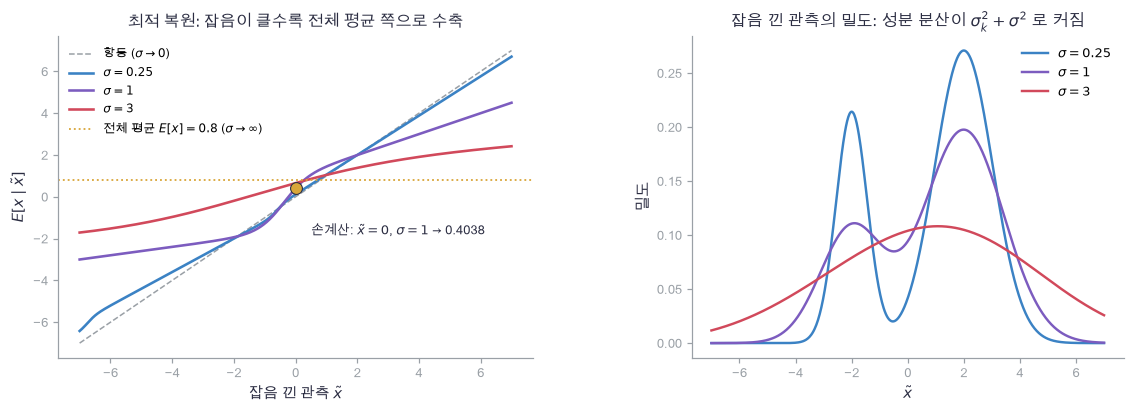

In [49]:
plot_denoiser_curves(mix_x, denoise_curves, denoise_sigmas, denoise_noisy, 0.0, denoise_hand, 1.0, 0.8)

🔍 **확인** · 왼쪽에서 회색 점선이 "받은 값을 그대로 쓰기"입니다. $\sigma=0.25$ 곡선은 거의 점선에 붙어 있지만 두 봉우리 사이에서 **계단처럼 꺾입니다.** 잡음이 조금만 있어도 "이건 오른쪽 봉우리에서 온 점"이라고 판단해 그쪽으로 당깁니다.
$\sigma$가 커질수록 곡선이 눕고 금색 점선(전체 평균 0.8) 쪽으로 수축합니다. 잡음이 크면 원래 값에 대한 정보가 적으니 안전한 평균으로 돌아가는 것입니다.
오른쪽은 잡음 낀 관측의 밀도입니다. $\sigma=3$이면 봉우리 두 개가 이미 하나로 뭉개졌습니다. 33·34번이 "큰 잡음에서 작은 잡음으로" 내려가며 샘플을 만드는 이유가 이 그림에 있습니다.

In [50]:
def mix_denoiser(x_noisy, sigma):
    """잡음 뒤 최적 복원 E[x | x̃] = Σ_k r_k^σ(x̃) [μ_k + σ_k²/(σ_k² + σ²) (x̃ − μ_k)].
    성분 분산이 σ_k² + σ² 인 책임확률로 성분별 조건부 평균을 가중합니다. x_noisy: (N,) → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · mix_responsibility (2절)
    variance = MIX_SIGMA ** 2 + sigma ** 2                           # (2,)
    conditional = MIX_MU + MIX_SIGMA ** 2 / variance * (x_noisy[:, None] - MIX_MU)   # (N, 2)
    return np.sum(mix_responsibility(x_noisy, sigma) * conditional, axis=1)


def mix2_denoiser(X_noisy, sigma):
    """2차원 최적 복원. 계수가 Σ_k(Σ_k + σ²I)⁻¹ 이고 책임확률도 그 공분산으로 다시 잰 것입니다. X_noisy: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀) · component2_log_terms (1절) · softmax_rows (2절)
    noisy_cov = MIX2_COV + sigma ** 2 * np.eye(2)                    # (2, 2, 2): Σ_k + σ²I
    R = softmax_rows(component2_log_terms(X_noisy, MIX2_PI, MIX2_MU, noisy_cov))     # (N, 2)
    out = np.zeros_like(X_noisy)
    for k in range(2):
        pulled = np.linalg.solve(noisy_cov[k], (X_noisy - MIX2_MU[k]).T).T           # (N, 2): (Σ_k+σ²I)⁻¹(x̃ − μ_k)
        out += R[:, k:k + 1] * (MIX2_MU[k] + pulled @ MIX2_COV[k].T)
    return out

In [51]:
# 쓰는 것: mix_x, denoise_curves, denoise_hand (5절 잡음 계산 셀) · MIX_PI, MIX_MU, MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀) · logsumexp_rows, component2_log_terms (1절)
np.testing.assert_allclose(mix_denoiser(mix_x, 1.0), denoise_curves[:, 1])        # 검산: 그림의 σ = 1 곡선
np.testing.assert_allclose(mix_denoiser(np.array([0.0]), 1.0), [0.403833], atol=1e-6)   # 검산: 손계산 E[x | x̃ = 0]
small_x = np.linspace(-5, 5, 41)
np.testing.assert_allclose(mix_denoiser(small_x, 1e-6), small_x, atol=1e-9)       # 검산: σ → 0 이면 항등(그대로 두기)
np.testing.assert_allclose(mix_denoiser(small_x, 200.0), np.full(41, 0.8), atol=1e-3)   # 검산: σ 가 크면 전체 평균 0.8
np.testing.assert_allclose(mix2_denoiser(np.zeros((1, 2)), 1e-6), np.zeros((1, 2)), atol=1e-9)   # 검산: 2차원도 σ → 0 이면 항등
tweedie2_X = np.random.default_rng(2310).uniform(-3, 3, size=(4, 2))   # (4, 2): 2차원 중심차분용 점


def noisy2_logpdf_sum():
    """검사기용: σ = 1 의 2차원 잡음 낀 분포 q_σ 의 로그 밀도 합. numerical_gradient 가 tweedie2_X 를 흔듭니다."""
    return float(np.sum(logsumexp_rows(component2_log_terms(tweedie2_X, MIX2_PI, MIX2_MU, MIX2_COV + np.eye(2)))))


tweedie2_error = rel_error(mix2_denoiser(tweedie2_X, 1.0) - tweedie2_X, numerical_gradient(noisy2_logpdf_sum, tweedie2_X))
assert tweedie2_error < 1e-7, "2차원에서도 (E[x | x̃] − x̃)/σ² 가 q_σ 의 score 와 같아야 합니다"
print("σ → 0 최대 오차", float(np.abs(mix_denoiser(small_x, 1e-6) - small_x).max()),
      "· σ = 200 최대 오차", float(np.abs(mix_denoiser(small_x, 200.0) - 0.8).max()))
print("2차원 (E[x | x̃] − x̃)/σ² 와 q_σ score 의 상대오차", tweedie2_error)

σ → 0 최대 오차 1.199129684437139e-11 · σ = 200 최대 오차 0.0005560113756180041
2차원 (E[x | x̃] − x̃)/σ² 와 q_σ score 의 상대오차 6.217376955320583e-10


In [52]:
# 쓰는 것: denoise_hand (5절 잡음 계산 셀) · mix_logpdf (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
mc_rng = np.random.default_rng(2307)
mc_z = mc_rng.choice(2, size=400000, p=MIX_PI)                       # 1. 잠재를 뽑고
mc_x0 = MIX_MU[mc_z] + MIX_SIGMA[mc_z] * mc_rng.normal(size=400000)  # 2. 원래 값을 뽑고
mc_noisy = mc_x0 + 1.0 * mc_rng.normal(size=400000)                  # 3. σ = 1 의 잡음을 더합니다
mc_near = np.abs(mc_noisy) < 0.1                                     # x̃ 가 0 근처인 표본만 골라
mc_estimate = float(mc_x0[mc_near].mean())                           # 그 원래 값들의 평균 = E[x | x̃ ≈ 0]
assert abs(mc_estimate - denoise_hand) < 0.05, "Monte Carlo 평균이 닫힌식과 0.05 안에서 같아야 합니다"
tweedie_x = np.random.default_rng(2308).uniform(-4, 4, size=5)       # (5,): 중심차분용 점


def noisy_logpdf_sum():
    """검사기용: σ = 1 의 잡음 낀 분포 q_σ 의 로그 밀도 합."""
    return float(np.sum(mix_logpdf(tweedie_x, 1.0)))


tweedie_error = rel_error(mix_denoiser(tweedie_x, 1.0) - tweedie_x, numerical_gradient(noisy_logpdf_sum, tweedie_x))
assert tweedie_error < 1e-7, "(E[x | x̃] − x̃)/σ² 와 q_σ 의 score 가 1e−7 안에서 같아야 합니다"
print("Monte Carlo", round(mc_estimate, 4), "(표본", int(mc_near.sum()), "개) · 닫힌식", round(denoise_hand, 4))
print("(E[x | x̃] − x̃)/σ² 와 q_σ score 의 상대오차", tweedie_error)

Monte Carlo 0.3814 (표본 7715 개) · 닫힌식 0.4038
(E[x | x̃] − x̃)/σ² 와 q_σ score 의 상대오차 4.77207944744149e-10


🔍 **확인** · 네 가지가 맞았습니다. (1) $\sigma\to0$이면 복원이 항등입니다. (2) $\sigma=200$이면 전체 평균 0.8에서 $10^{-3}$ 안입니다. (3) 잡음을 실제로 400,000번 더해 $\tilde x$가 0 근처인 표본의 원래 값을 평균낸 Monte Carlo 추정이 닫힌식 0.4038과 0.05 안에서 같습니다.
(4) $\sigma=1$에서 $(\mathbb E[x\mid\tilde x]-\tilde x)/\sigma^2$가 잡음 낀 분포 $q_\sigma$의 score(중심차분)와 1·2차원 모두 $10^{-9}$ 수준에서 같습니다. **따로 유도한 두 식이 만납니다.** 32번은 이 관계를 Tweedie 공식이라는 이름으로 쓰고, 34·35b번은 이것으로 denoiser와 score를 오갑니다.

### ✏️ 연습 5-1 · 균등 난수로 성분 고르기

`rng.choice` 없이 균등 난수 `u` `(n,)`와 비율 `pi` `(K,)`만으로 잠재 성분 `z` `(n,)`를 고릅니다. 누적 확률 `cumulative` 는 써 두었으니 $u$가 들어갈 칸을 찾는 한 줄을 채우세요. ancestral sampling 의 첫 줄을 손으로 써 보는 연습입니다.

In [53]:

def exercise_choose_component(u, pi):
    """연습 5-1: 균등 난수에서 잠재 성분 번호를 고릅니다. u: (n,) 0–1 난수, pi: (K,) → z: (n,) 정수."""
    assert abs(float(pi.sum()) - 1.0) < 1e-12, "비율의 합은 1 이어야 합니다"
    cumulative = np.cumsum(pi)                                       # (K,): 누적 확률. 마지막은 1
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: z = u 가 누적 확률의 어느 칸에 들어가는지 찾은 (n,) 정수 배열
    ### 힌트: np.searchsorted(cumulative, u) 한 줄입니다. u < pi[0] 이면 0, 그다음 구간이면 1 이 나옵니다.
    raise NotImplementedError
    return z

In [54]:

def check_choose_component(candidate):
    """손계산 세 값과 큰 표본의 비율, 그리고 성분 세 개인 경우로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: MIX_PI (📎 혼합 상수 셀)
    hand_u = np.array([0.1, 0.35, 0.9])                              # 누적 [0.3, 1.0] 기준으로 0, 1, 1
    actual = candidate(hand_u, MIX_PI)
    assert np.shape(actual) == (3,), f"난수마다 성분 하나이므로 (3,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_array_equal(actual, [0, 1, 1])                 # 검산: 0.1 < 0.3 이면 성분 0, 나머지는 성분 1
    many = candidate(np.random.default_rng(235).uniform(size=40000), MIX_PI)
    assert abs(float((many == 0).mean()) - 0.3) < 0.01, "40,000개에서 성분 0 의 비율이 0.3 에서 0.01 안이어야 합니다"
    three = candidate(np.array([0.1, 0.45, 0.8]), np.array([0.2, 0.5, 0.3]))
    np.testing.assert_array_equal(three, [0, 1, 2])                  # 검산: 누적 [0.2, 0.7, 1.0] 의 세 칸
    print("성분 고르기: 손계산·비율과 일치합니다.")

run_check(check_choose_component, exercise_choose_component, hint="z = np.searchsorted(cumulative, u)")

☐ exercise_choose_component: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: z = np.searchsorted(cumulative, u)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
z = np.searchsorted(cumulative, u)
```

</details>

### ✏️ 연습 5-2 · 잡음 뒤의 최적 복원 한 줄

잡음 낀 관측 `x_noisy` `(N,)`에서 원래 값을 추측합니다. 성분별 조건부 평균 `conditional` `(N, 2)`는 써 두었으니, 분산이 $\sigma_k^2+\sigma^2$로 커진 책임확률로 가중해 성분 축을 더하는 한 줄을 채우세요. 34·35b번이 diffusion에서 되풀이해 쓰는 denoiser를 손으로 써 보는 연습입니다.

In [55]:

def exercise_denoise(x_noisy, sigma):
    """연습 5-2: 잡음 뒤의 최적 복원 E[x | x̃]를 책임확률의 가중합으로 구합니다. x_noisy: (N,), sigma: 잡음 표준편차 → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · mix_responsibility (2절)
    variance = MIX_SIGMA ** 2 + sigma ** 2                           # (2,): 잡음을 더한 성분 분산 σ_k² + σ²
    conditional = MIX_MU + MIX_SIGMA ** 2 / variance * (x_noisy[:, None] - MIX_MU)   # (N, 2): 성분별 조건부 평균
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: out = 잡음 뒤 책임확률 r^σ 로 conditional 을 가중해 성분 축을 더한 (N,) 배열
    ### 힌트: mix_responsibility(x_noisy, sigma) 가 (N, 2) 입니다. conditional 과 곱하고 axis=1 로 더합니다.
    raise NotImplementedError
    return out

In [56]:

def check_denoise(candidate):
    """손계산 0.403833(σ = 1, x̃ = 0)과 σ → 0 항등, σ = 200 의 전체 평균으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: MIX_PI, MIX_MU (📎 혼합 상수 셀)
    hand = candidate(np.array([0.0]), 1.0)
    assert np.shape(hand) == (1,), f"관측 하나에 값 하나이므로 (1,) 여야 하는데 {np.shape(hand)} 입니다"
    np.testing.assert_allclose(hand, [0.403833], atol=1e-6)          # 검산: 손계산 E[x | x̃ = 0] = 0.403833
    grid = np.linspace(-5, 5, 41)                                    # (41,): σ 를 양 끝으로 보내 볼 자리
    np.testing.assert_allclose(candidate(grid, 1e-6), grid, atol=1e-9)   # 검산: σ → 0 이면 받은 값 그대로
    np.testing.assert_allclose(candidate(grid, 200.0), np.full(41, float(np.sum(MIX_PI * MIX_MU))), atol=1e-3)   # 검산: σ 가 크면 전체 평균 0.8
    print("최적 복원: 손계산 0.403833·σ → 0 항등·σ = 200 의 0.8 과 모두 일치합니다.")

run_check(check_denoise, exercise_denoise, hint="out = np.sum(mix_responsibility(x_noisy, sigma) * conditional, axis=1)")

☐ exercise_denoise: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: out = np.sum(mix_responsibility(x_noisy, sigma) * conditional, axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
out = np.sum(mix_responsibility(x_noisy, sigma) * conditional, axis=1)
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 반복문으로 쓴 주변 밀도 (1절)

1절은 로그로 더했습니다. 여기서는 성분 반복문을 돌며 밀도를 그대로 더해 $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$를 만듭니다. 성분이 몇 개든 같은 줄이어야 합니다.

In [57]:
def exercise_marginal_loop(x, pi, mu, sigma):
    """연습 A: 반복문으로 주변 밀도 p(x) = Σ_k π_k N(x; μ_k, σ_k²). x: (N,), pi·mu·sigma: (K,) → (N,)."""
    assert len(pi) == len(mu), "비율과 평균의 성분 수가 같아야 합니다"
    total = np.zeros(len(x))                                         # (N,): 성분 밀도를 여기에 더합니다
    for k in range(len(pi)):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 성분 k 의 π_k N(x; μ_k, σ_k²) 를 total 에 더하기
        ### 힌트: 1절 계산 셀의 가중 성분 밀도를 성분 하나에 대해 쓴 것입니다. 정규화 상수는 1/√(2π σ_k²) 입니다.
        raise NotImplementedError
    return total

In [58]:
def check_marginal_loop(candidate):
    """1절 손계산 p(0), 격자 전체의 밀도, 그리고 성분 세 개인 경우로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_x, mix_total (1절 계산 셀) · mix_logpdf, component_log_terms, logsumexp_rows (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    actual = candidate(np.array([0.0]), MIX_PI, MIX_MU, MIX_SIGMA)
    assert np.shape(actual) == (1,), f"점마다 값 하나이므로 (1,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [0.037874], atol=1e-6)                     # 검산: 1절 손계산 p(0)
    np.testing.assert_allclose(candidate(mix_x, MIX_PI, MIX_MU, MIX_SIGMA), mix_total)   # 검산: 1절 격자의 밀도
    three_pi, three_mu, three_sigma = np.array([0.2, 0.5, 0.3]), np.array([-3., 0., 3.]), np.array([0.6, 0.8, 0.7])
    reference = np.exp(logsumexp_rows(component_log_terms(mix_x, three_pi, three_mu, three_sigma)))
    np.testing.assert_allclose(candidate(mix_x, three_pi, three_mu, three_sigma), reference)   # 검산: 성분 3개도 logsumexp 경로와 같음
    print("반복문 주변 밀도: 손계산·logsumexp 경로와 일치합니다.")

run_check(check_marginal_loop, exercise_marginal_loop,
          hint="total += pi[k] * np.exp(-0.5 * (x - mu[k]) ** 2 / sigma[k] ** 2) / np.sqrt(2 * np.pi * sigma[k] ** 2)")

☐ exercise_marginal_loop: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: total += pi[k] * np.exp(-0.5 * (x - mu[k]) ** 2 / sigma[k] ** 2) / np.sqrt(2 * np.pi * sigma[k] ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
total += pi[k] * np.exp(-0.5 * (x - mu[k]) ** 2 / sigma[k] ** 2) / np.sqrt(2 * np.pi * sigma[k] ** 2)
```

</details>

### ✏️ 연습 B · 2차원 책임확률 (2절)

2차원 점 `X` `(N, 2)`에서 책임확률 `(N, 2)`를 만듭니다. 성분 로그 항을 만드는 함수는 1절에 있고 softmax 는 2절에 있습니다. 두 줄을 이어 붙이는 한 줄을 채우세요.

In [59]:
def exercise_mix2_responsibility(X):
    """연습 B: 2차원 혼합의 책임확률 r_k(x) = p(z = k | x). X: (N, 2) → (N, 2), 행 합 1."""
    assert X.shape[1] == 2, "2차원 점은 (N, 2) 여야 합니다"
    terms = component2_log_terms(X, MIX2_PI, MIX2_MU, MIX2_COV)      # (N, 2): log π_k + log N(x; μ_k, Σ_k)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: R = terms 의 행마다 softmax (모양 (N, 2))
    ### 힌트: 2절 softmax_rows 를 그대로 부르면 됩니다. 1차원과 달라지는 것은 로그 항을 만드는 방법뿐입니다.
    raise NotImplementedError
    return R

In [60]:
def check_mix2_responsibility(candidate):
    """성분 0 의 평균에서 손계산한 값과 본문 mix2_responsibility 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix2_responsibility (2절) · MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 상수 셀)
    point = MIX2_MU[0][None, :]                                      # (1, 2): 성분 0 의 평균
    actual = candidate(point)
    assert actual.shape == (1, 2), f"책임확률은 (1, 2) 여야 하는데 {np.shape(actual)} 입니다"
    hand = np.zeros(2)                                               # 역행렬을 직접 써서 2차원 밀도를 손으로 계산
    for k in range(2):
        difference = MIX2_MU[0] - MIX2_MU[k]
        a, b, c, d = MIX2_COV[k].ravel()                             # 2×2 의 네 원소
        determinant = a * d - b * c
        quadratic = (d * difference[0] ** 2 - (b + c) * difference[0] * difference[1] + a * difference[1] ** 2) / determinant
        hand[k] = MIX2_PI[k] * np.exp(-0.5 * quadratic) / (2 * np.pi * np.sqrt(determinant))
    np.testing.assert_allclose(actual, [hand / hand.sum()], atol=1e-12)   # 검산: 직접 쓴 2×2 역행렬 경로와 같음
    grid = np.random.default_rng(236).uniform(-4, 4, size=(7, 2))
    np.testing.assert_allclose(candidate(grid).sum(axis=1), 1.0)          # 검산: 행 합 = 1
    np.testing.assert_allclose(candidate(grid), mix2_responsibility(grid))   # 검산: 본문 구현과 같음
    print("2차원 책임확률: 손계산·본문 구현과 일치합니다.")

run_check(check_mix2_responsibility, exercise_mix2_responsibility, hint="R = softmax_rows(terms)")

☐ exercise_mix2_responsibility: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: R = softmax_rows(terms)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
R = softmax_rows(terms)
```

</details>

### ✏️ 연습 C · 평균 쪽 기울기 (3절)

관측 `x` `(N,)`, 책임확률 `R` `(N, K)`, 파라미터에서 평균 로그우도의 $\mu$ 기울기
$\partial/\partial\mu_k=\frac1N\sum_nr_{nk}(x_n-\mu_k)/\sigma_k^2$를 만듭니다. 관측 축에서 **평균**, 성분 축은 그대로 두는 것이 핵심입니다.

In [61]:
def exercise_dmu(x, R, mu, sigma):
    """연습 C: 평균 로그우도의 μ 기울기. x: (N,), R: (N, K), mu·sigma: (K,) → (K,)."""
    assert R.shape == (len(x), len(mu)), "책임확률은 (N, K) 여야 합니다"
    difference = x[:, None] - mu                                     # (N, K): x_n − μ_k
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dmu = R 로 가중한 difference / sigma² 를 관측 축에서 평균낸 (K,) 배열
    ### 힌트: 3절 mix_param_gradients 의 dmu 한 줄입니다. 더하는 것이 아니라 평균(.mean)이고 축은 0 입니다.
    raise NotImplementedError
    return dmu

In [62]:
def check_dmu(candidate):
    """3절 손계산 막대와 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: score_dmu0 (3절 계산 셀) · mix_responsibility, softmax_rows (2절) · mix_mean_loglik (3절) · component_log_terms (1절) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    zero = np.array([0.0])
    actual = candidate(zero, mix_responsibility(zero), MIX_MU, MIX_SIGMA)
    assert np.shape(actual) == (2,), f"성분마다 기울기 하나이므로 (2,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [0.016961, -1.995760], atol=1e-6)   # 검산: 3절 손계산 ∂log p/∂μ
    np.testing.assert_allclose(actual, score_dmu0)                         # 검산: 3절 그림의 막대 두 개
    local_x = np.random.default_rng(237).normal(size=30) * 1.5             # (30,): 다른 파라미터에서도 맞는지
    local_mu, local_sigma = np.array([-1.0, 1.5]), np.array([0.9, 1.1])
    local_R = softmax_rows(component_log_terms(local_x, MIX_PI, local_mu, local_sigma))   # (30, 2): 그 파라미터의 E 단계

    def local_mean_loglik():
        """검사기용: local 파라미터에서의 평균 로그우도. numerical_gradient 가 local_mu 를 흔듭니다."""
        return mix_mean_loglik(local_x, MIX_PI, local_mu, local_sigma)

    error = rel_error(candidate(local_x, local_R, local_mu, local_sigma), numerical_gradient(local_mean_loglik, local_mu))
    assert error < 1e-7, f"중심차분과의 상대오차 {error:.2e} 가 1e−7 아래여야 합니다"
    print("μ 기울기: 손계산·중심차분과 일치합니다.")

run_check(check_dmu, exercise_dmu, hint="dmu = (R * difference / sigma ** 2).mean(axis=0)")

☐ exercise_dmu: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dmu = (R * difference / sigma ** 2).mean(axis=0)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dmu = (R * difference / sigma ** 2).mean(axis=0)
```

</details>

### ✏️ 연습 D · M 단계의 비율 갱신 (4절)

책임확률 `R` `(N, K)`에서 새 비율 $\pi_k=N_k/N$을 만듭니다. 한 줄이지만 **어느 축을 더하는지**와 **무엇으로 나누는지**를 헷갈리기 쉽습니다.

In [63]:
def exercise_m_step_pi(R):
    """연습 D: M 단계의 비율 갱신 π_k = N_k / N = (Σ_n r_nk) / N. R: (N, K) → (K,), 합 1."""
    assert R.ndim == 2, "책임확률은 (N, K) 2차원이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: pi = R 을 관측 축에서 더한 뒤 관측 수로 나눈 (K,) 배열
    ### 힌트: 4절 em_step 의 마지막 줄 weight / len(x) 입니다. 관측 축은 0 이고 관측 수는 len(R) 입니다.
    raise NotImplementedError
    return pi

In [64]:
def check_m_step_pi(candidate):
    """4절 손계산 네 점과 em_step 의 결과, 그리고 합이 1인지로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: em_hand_x, em_hand_r, em_hand_pi, em_hand_mu, em_hand_sigma (4절 손계산 셀) · em_step (4절)
    actual = candidate(em_hand_r)
    assert np.shape(actual) == (2,), f"성분마다 비율 하나이므로 (2,) 여야 하는데 {np.shape(actual)} 입니다"
    np.testing.assert_allclose(actual, [0.591321, 0.408679], atol=1e-6)   # 검산: 4절 손계산 π = N_k/4
    np.testing.assert_allclose(actual.sum(), 1.0)                         # 검산: 비율의 합 = 1
    reference = em_step(em_hand_x, em_hand_pi, em_hand_mu, em_hand_sigma)[0]
    np.testing.assert_allclose(actual, reference)                         # 검산: em_step 의 새 π 와 같음
    hard = np.array([[1., 0.], [1., 0.], [0., 1.], [0., 1.]])             # 0/1 이면 그냥 개수 비율
    np.testing.assert_allclose(candidate(hard), [0.5, 0.5])               # 검산: 2 대 2 이면 (0.5, 0.5)
    print("M 단계의 비율: 손계산·em_step 과 일치합니다.")

run_check(check_m_step_pi, exercise_m_step_pi, hint="pi = R.sum(axis=0) / len(R)")

☐ exercise_m_step_pi: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: pi = R.sum(axis=0) / len(R)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
pi = R.sum(axis=0) / len(R)
```

</details>

### 🔍 완성 예제 · 성분 3개 혼합에서 시작값을 바꾸면

4절의 `em_step`은 성분 수 $K$에 상관없이 그대로 돌아갑니다. 봉우리 세 개짜리 데이터에 같은 함수를 쓰되, **시작값만 두 가지**로 두고 60반복씩 돌립니다.
시작값 A는 세 평균을 넓게 펼쳐 두고, 시작값 B는 세 평균을 오른쪽 봉우리 위에 몰아 두고 표준편차도 좁게 둡니다. 둘 다 로그우도는 내려가지 않지만 도착하는 곳이 다릅니다. 학습용 작은 문제입니다.

In [65]:
# 쓰는 것: mix_x (1절 계산 셀) · em_step (4절) · component_log_terms (1절)
MIX3_PI, MIX3_MU, MIX3_SIGMA = np.array([0.25, 0.35, 0.40]), np.array([-3., 0., 3.]), np.array([0.6, 0.8, 0.7])
variant_rng = np.random.default_rng(2303)
variant_z = variant_rng.choice(3, size=900, p=MIX3_PI)               # (900,): 성분 세 개의 잠재
variant_data = MIX3_MU[variant_z] + MIX3_SIGMA[variant_z] * variant_rng.normal(size=900)   # (900,)
variant_starts = {"시작값 A": (np.array([-3., 0., 3.]), np.ones(3)),
                  "시작값 B": (np.array([2.6, 3.0, 3.4]), np.full(3, 0.3))}
variant_fits, variant_logliks = [], {}
for name, (start_mu, start_sigma) in variant_starts.items():
    pi_v, mu_v, sigma_v, history = np.ones(3) / 3, start_mu.copy(), start_sigma.copy(), []
    for _ in range(60):
        pi_v, mu_v, sigma_v, value = em_step(variant_data, pi_v, mu_v, sigma_v)
        history.append(value)
    weighted_v = np.exp(component_log_terms(mix_x, pi_v, mu_v, sigma_v))         # (701, 3): 학습된 성분 곡선
    start_text = ", ".join(f"{value:g}" for value in start_mu)                   # 제목에 적을 시작 평균
    variant_fits.append((f"{name}: 시작 $\\mu = ({start_text})$\n평균 로그우도 {history[-1]:.4f}", weighted_v, weighted_v.sum(axis=1)))
    variant_logliks[name] = history
    assert np.all(np.diff(history) >= -1e-12), "성분 3개에서도 로그우도는 내려가지 않아야 합니다"
    print(f"{name}: 평균 로그우도 {history[-1]:.5f} · μ {mu_v.round(3)} · π {pi_v.round(3)} · σ {sigma_v.round(3)}")

시작값 A: 평균 로그우도 -2.07516 · μ [-3.024  0.142  2.972] · π [0.264 0.364 0.372] · σ [0.609 0.815 0.671]
시작값 B: 평균 로그우도 -2.19555 · μ [-0.733  2.806  3.376] · π [0.713 0.157 0.13 ] · σ [2.067 0.472 0.476]


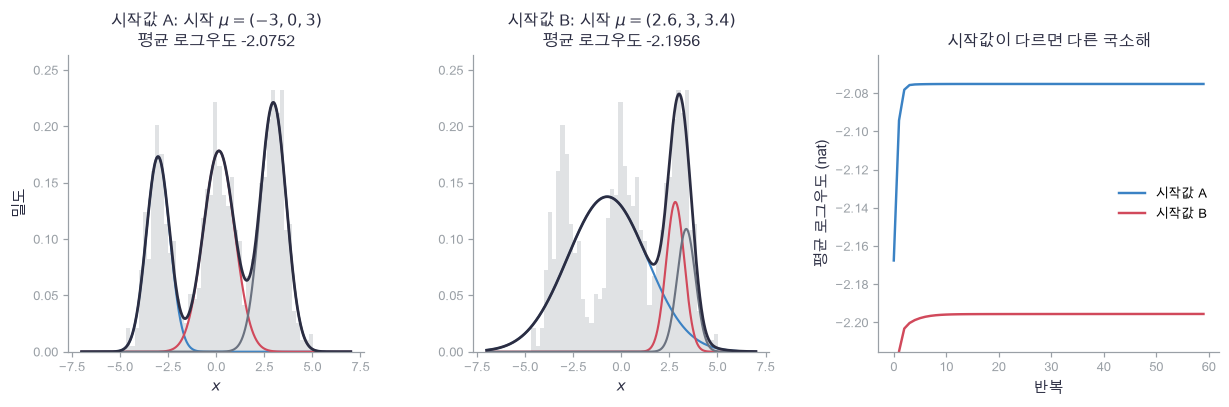

In [66]:
plot_em_variants(mix_x, variant_data, variant_fits, variant_logliks)

🔍 **확인** · 시작값 A는 세 봉우리를 하나씩 맡아 참값 $\mu=(-3,0,3)$에 가깝게 갑니다. 시작값 B는 오른쪽 봉우리를 성분 두 개가 나눠 가지고, 남은 성분 하나가 표준편차 2.07의 넓은 곡선으로 왼쪽 전부를 덮습니다.
평균 로그우도는 $-2.075$ 대 $-2.196$으로 A가 더 큽니다. **둘 다 EM의 규칙을 어기지 않았는데 도착점이 다릅니다.** 오른쪽 곡선에서 두 선 모두 단조 증가한 뒤 서로 다른 높이에서 평평해집니다. 단, **B의 반복 0은 $-61.6$이라 눈금 밖입니다**(표준편차 0.3을 세 성분 모두에 둔 탓이고, 한 반복 만에 눈금 안으로 올라옵니다).
그래서 실제로는 시작값을 여러 개 써 보고 로그우도가 가장 큰 것을 고릅니다. "내려가지 않는다"는 보장은 **전체 최선**을 뜻하지 않습니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 잠재변수를 "더해서 없앤다"는 것이 무엇이고, 그 합의 분모가 왜 책임확률의 분모와 같은지 말할 수 있나요? → 1·2절
- **수식:** $r_k(x)$, $\partial\log p/\partial\mu_k$, $\partial\log p/\partial x$를 shape와 함께 쓰고, 셋이 모두 같은 $r$의 가중합임을 보일 수 있나요? → 2·3절
- **구현:** E 단계와 M 단계를 각각 몇 줄로 쓰고, 어느 축을 더하고 무엇으로 나누는지 설명할 수 있나요? → 4절
- **변형:** 성분 수나 시작값을 바꾸면 어떻게 달라지는지, 잡음 $\sigma$를 키우면 최적 복원이 왜 전체 평균으로 수축하는지 설명할 수 있나요? → 4·5절

다음은 [24 ELBO](24_elbo.ipynb)입니다. 이 노트북에서는 잠재가 두 개(또는 열 개)라 다 더할 수 있었습니다. 잠재가 연속이거나 고차원이면 그 합을 계산할 수 없고, 그때 $\log p(x)$ 대신 무엇을 최대화할지가 문제가 됩니다. 답은 여기서 만든 책임확률과 이어집니다.

📎 EM은 Dempster·Laird·Rubin의 1977년 논문(*JRSS B* 39(1) 1–38)에서 이름과 일반형이 정리되었고, 혼합 모형과 EM의 교과서 설명은 [Bishop, *Pattern Recognition and Machine Learning*](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) 9장입니다.
"EM이 사실은 하한을 올리는 반복"이라는 관점은 [Neal·Hinton (1998)](https://www.cs.toronto.edu/~radford/ftp/emk.pdf)에 있고, 그 하한이 바로 24번의 ELBO입니다. 이 노트북의 예제와 숫자는 설명을 위해 새로 구성한 것입니다.